# Klasyfikacja uderzeń serca w zapisie EKG na podstawie cech sygnałowych i okien czasowych

**Projekt:** Rozpoznawanie nieprawidłowych uderzeń serca na podstawie sygnału EKG  
**Przedmiot:** Akwizycja danych biomedycznych    
**Autorzy:** Ewa Kędziera, Jan Rapacz

---

Celem tej części projektu jest realizacja drugiego podejścia do klasyfikacji uderzeń serca. W przeciwieństwie do baseline'u RR, wykorzystywana jest tutaj bogatsza reprezentacja sygnału EKG, obejmująca nie tylko rytm, ale także morfologię fragmentów sygnału wokół uderzeń.

Realizowane są dwa warianty:

1. **Klasyczne uczenie maszynowe na cechach**  
   Ręczna ekstrakcja cech rytmu, morfologii i jakości sygnału, a następnie klasyfikacja modelami tabularnymi.

2. **Deep learning na oknach sygnału**  
   Segmentacja sygnału wokół adnotowanych uderzeń i klasyfikacja za pomocą sieci konwolucyjnej 1D.

Oba warianty korzystają z reprezentacji sygnałowej, a nie wyłącznie z odstępów RR.

## Założenia metodologiczne

W projekcie analizowane są pojedyncze uderzenia serca. Każde uderzenie jest opisane przez:

- pozycję próbki odpowiadającą adnotowanemu uderzeniu,
- oryginalny symbol MIT-BIH, np. `N`, `V`, `A`, `L`, `R`,
- klasę AAMI,
- etykietę binarną: `normal` albo `abnormal`,
- rekord, z którego pochodzi uderzenie,
- fragment sygnału EKG wokół tego uderzenia.

Głównym celem jest klasyfikacja binarna:

```text
normal vs abnormal
```

Domyślnie stosowany jest wariant:

```text
normal   = AAMI N
abnormal = AAMI S, V, F
pomijane = AAMI Q
```

Klasa `Q` jest pomijana, ponieważ obejmuje m.in. uderzenia stymulowane rozrusznikiem, fusion paced beats i uderzenia nieklasyfikowalne. Włączenie jej do klasy `abnormal` może zaburzać interpretację biomedyczną, bo model częściowo uczyłby się wykrywania rozrusznika lub niepewnych adnotacji, a nie tylko typowych nieprawidłowości rytmu.

Najważniejsze założenia projektowe:

1. **Brak losowego podziału pojedynczych uderzeń.**  
   Uderzenia z tego samego rekordu/pacjenta nie mogą znajdować się jednocześnie w treningu i teście.

2. **Podział inter-patient DS1/DS2.**  
   Rekordy treningowe i testowe są rozłączne.

3. **Filtracja sygnału przed ekstrakcją cech.**  
   Sygnał EKG jest filtrowany pasmowo, aby ograniczyć dryft linii bazowej i zakłócenia wysokoczęstotliwościowe.

4. **Oddzielenie walidacji od testu.**  
   Próg decyzyjny i hiperparametry są dobierane na walidacji, a test DS2 jest używany dopiero do finalnej oceny.


## Źródła i odniesienia

Najważniejsze źródła wykorzystane przy konstrukcji metodologii:

- **MIT-BIH Arrhythmia Database, PhysioNet** - oficjalny opis zbioru, liczba rekordów, częstotliwość próbkowania i charakter adnotacji: https://physionet.org/content/mitdb/1.0.0/
- **WFDB Python package** - narzędzie do pobierania i czytania rekordów PhysioNet: https://wfdb.readthedocs.io/
- **AAMI EC57 / grupowanie AAMI** - w literaturze MIT-BIH często stosuje się nadklasy `N`, `S`, `V`, `F`, `Q`.
- **Inter-patient split DS1/DS2** - popularny podział używany do ograniczenia przecieku danych między pacjentami.
- **scikit-learn GroupKFold / grupowe dzielenie danych** - walidacja z nieprzecinającymi się grupami: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html
- **Keras Conv1D** - konwolucje jednowymiarowe dla sekwencji czasowych: https://keras.io/api/layers/convolution_layers/convolution1d/


## Przygotowanie środowiska

### Instalacja i import bibliotek

W projekcie wykorzystano biblioteki:

- `wfdb` - wczytywanie sygnałów i adnotacji z PhysioNet,
- `numpy`, `pandas` - przetwarzanie danych,
- `scipy` - filtracja i analiza sygnałów,
- `scikit-learn` - modele klasycznego uczenia maszynowego,
- `tensorflow/keras` - model deep learning 1D CNN,
- `matplotlib` - wykresy.




In [6]:
from __future__ import annotations

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as scipy_signal
from scipy import stats

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

try:
    import joblib
    HAS_JOBLIB = True
except Exception:
    HAS_JOBLIB = False

try:
    import wfdb
    HAS_WFDB = True
except Exception as exc:
    HAS_WFDB = False
    WFDB_IMPORT_ERROR = exc

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as exc:
    HAS_TF = False
    TF_IMPORT_ERROR = exc

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

print("wfdb available:", HAS_WFDB)
print("tensorflow available:", HAS_TF)
print("StratifiedGroupKFold available:", HAS_STRATIFIED_GROUP_KFOLD)


wfdb available: True
tensorflow available: True
StratifiedGroupKFold available: True


### Konfiguracja projektu

Najważniejsze parametry projektu:

- `PRE_SEC` i `POST_SEC` określają długość okna wokół uderzenia,
- `LOWCUT_HZ` i `HIGHCUT_HZ` określają pasmo filtru,
- `INCLUDE_Q_AS_ABNORMAL` pozwala zdecydować, czy klasa `Q` ma być włączona do problemu binarnego,
- `FAST_RUN` pozwala uruchomić notebook na kilku rekordach do testów technicznych.


In [7]:
DATASET_NAME = "mitdb"
LOCAL_DATA_DIR = None
OUTPUT_DIR = Path("outputs_dir")
OUTPUT_DIR.mkdir(exist_ok=True)

# Segmentacja uderzenia wokół adnotowanego punktu R / pozycji beat annotation.
PRE_SEC = 0.25
POST_SEC = 0.45

# Filtracja EKG. Pasmo 0.5-40 Hz jest typowym kompromisem dla analizy morfologii QRS
# i ograniczenia dryftu linii bazowej oraz zakłóceń wysokoczęstotliwościowych.
LOWCUT_HZ = 0.5
HIGHCUT_HZ = 40.0
FILTER_ORDER = 4

# Główny wariant metodologiczny.
INCLUDE_Q_AS_ABNORMAL = False

# Tryb testowy.
FAST_RUN = False
FAST_RUN_RECORDS_PER_SPLIT = 3

# Deep learning.
RUN_DEEP_LEARNING = True
CNN_EPOCHS = 60
CNN_BATCH_SIZE = 256
CNN_LEARNING_RATE = 1e-3

# Strojenie progu decyzyjnego.
THRESHOLD_OBJECTIVE = "f1"  # "f1" albo "high_sensitivity"
MIN_SENSITIVITY_FOR_THRESHOLD = 0.90


## Przygotowanie danych

### Rekordy MIT-BIH i podział DS1/DS2

MIT-BIH zawiera 48 półgodzinnych zapisów EKG. W wielu pracach wykorzystuje się podział inter-patient DS1/DS2, który zmniejsza ryzyko przecieku informacji między treningiem i testem.

W tym notebooku stosowany jest następujący schemat:

- **DS1** - zbiór, z którego wydzielana jest część treningowa i walidacyjna,
- **DS2** - finalny zbiór testowy,
- rekordy `102`, `104`, `107`, `217` są pominięte w głównym eksperymencie, ponieważ zawierają uderzenia stymulowane rozrusznikiem.

To ważne, ponieważ rozrusznik może generować bardzo charakterystyczne wzorce sygnałowe, których obecność może zawyżać wyniki klasyfikacji, ale niekoniecznie oznacza lepsze rozpoznawanie typowych arytmii.


In [8]:
RECORDS = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201", "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214", "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231", "232", "233", "234",
]

PACED_RECORDS = ["102", "104", "107", "217"]

DS1_TRAIN = [
    "101", "106", "108", "109", "112", "114", "115", "116", "118", "119", "122", "124",
    "201", "203", "205", "207", "208", "209", "215", "220", "223", "230",
]

DS2_TEST = [
    "100", "103", "105", "111", "113", "117", "121", "123", "200", "202", "210", "212",
    "213", "214", "219", "221", "222", "228", "231", "232", "233", "234",
]

MODEL_RECORDS = DS1_TRAIN + DS2_TEST

if FAST_RUN:
    MODEL_RECORDS = DS1_TRAIN[:FAST_RUN_RECORDS_PER_SPLIT] + DS2_TEST[:FAST_RUN_RECORDS_PER_SPLIT]


def split_name(record_id: str) -> str:
    if record_id in DS1_TRAIN:
        return "DS1"
    if record_id in DS2_TEST:
        return "DS2"
    return "excluded"

print("Liczba rekordów DS1:", len(DS1_TRAIN))
print("Liczba rekordów DS2:", len(DS2_TEST))
print("Liczba rekordów użytych w tym uruchomieniu:", len(MODEL_RECORDS))
print("Rekordy użyte:", MODEL_RECORDS)
print("Rekordy wyłączone z głównego eksperymentu:", sorted(set(RECORDS) - set(DS1_TRAIN) - set(DS2_TEST)))


Liczba rekordów DS1: 22
Liczba rekordów DS2: 22
Liczba rekordów użytych w tym uruchomieniu: 44
Rekordy użyte: ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230', '100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']
Rekordy wyłączone z głównego eksperymentu: ['102', '104', '107', '217']


### Mapowanie adnotacji do klas AAMI

Oryginalne symbole MIT-BIH są dość szczegółowe. Do klasyfikacji uderzeń często grupuje się je do nadklas AAMI:

| Klasa AAMI | Znaczenie | Przykładowe symbole MIT-BIH |
|---|---|---|
| `N` | uderzenia normalne i przewodzeniowe | `N`, `L`, `R`, `e`, `j` |
| `S` | nadkomorowe uderzenia ektopowe | `A`, `a`, `J`, `S` |
| `V` | komorowe uderzenia ektopowe | `V`, `E` |
| `F` | fusion beat | `F` |
| `Q` | paced / unknown / unclassifiable | `/`, `f`, `Q` |

Dla problemu binarnego podstawowym celem jest rozróżnienie uderzeń prawidłowych od nieprawidłowych. Wariant domyślny:

```text
N       -> normal
S,V,F   -> abnormal
Q       -> ignore
```


In [9]:
AAMI_GROUPS = {
    "N": ["N", "L", "R", "e", "j"],
    "S": ["A", "a", "J", "S"],
    "V": ["V", "E"],
    "F": ["F"],
    "Q": ["/", "f", "Q"],
}

SYMBOL_TO_AAMI = {
    symbol: group
    for group, symbols in AAMI_GROUPS.items()
    for symbol in symbols
}


def map_to_aami(symbol: str) -> str:
    return SYMBOL_TO_AAMI.get(symbol, "ignore")


def map_to_binary_task(aami_class: str) -> str:
    if aami_class == "N":
        return "normal"
    if aami_class in ["S", "V", "F"]:
        return "abnormal"
    if INCLUDE_Q_AS_ABNORMAL and aami_class == "Q":
        return "abnormal"
    return "ignore"


LABEL_TO_INT = {"normal": 0, "abnormal": 1}
INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}

print("Mapowanie AAMI:")
for group, symbols in AAMI_GROUPS.items():
    print(f"  {group}: {symbols}")
print("INCLUDE_Q_AS_ABNORMAL:", INCLUDE_Q_AS_ABNORMAL)


Mapowanie AAMI:
  N: ['N', 'L', 'R', 'e', 'j']
  S: ['A', 'a', 'J', 'S']
  V: ['V', 'E']
  F: ['F']
  Q: ['/', 'f', 'Q']
INCLUDE_Q_AS_ABNORMAL: False


### Przetwarzanie sygnału EKG

Sygnał EKG jest sygnałem biomedycznym, dlatego przed uczeniem modeli należy wykonać uzasadnione przetwarzanie sygnału.

Zastosowane są następujące kroki:

1. **Wybór kanału.**  
   Preferowany jest kanał `MLII`, ponieważ dobrze pokazuje rytm i zespoły QRS. Jeżeli dany rekord go nie ma, wybierany jest pierwszy dostępny kanał.

2. **Interpolacja ewentualnych braków.**  
   Gdyby w sygnale pojawiły się wartości brakujące, są uzupełniane liniowo.

3. **Filtracja pasmowoprzepustowa 0.5–40 Hz.**  
   Dolna granica ogranicza dryft linii bazowej, a górna ogranicza zakłócenia wysokoczęstotliwościowe. Zastosowano filtr Butterwortha w reprezentacji SOS i filtrację zero-phase (`sosfiltfilt`), aby nie przesuwać adnotowanych pozycji uderzeń.

4. **Segmentacja uderzeń.**  
   Dla każdego adnotowanego uderzenia wycinane jest okno: ***0.25 s przed adnotacją + 0.45 s po adnotacji***

Przy częstotliwości 360 Hz daje to 252 próbki. Okno obejmuje fragment przed zespołem QRS, sam zespół QRS i fragment po uderzeniu.


In [10]:
def require_wfdb() -> None:
    if not HAS_WFDB:
        raise ImportError(
            "Biblioteka wfdb nie jest dostępna. Zainstaluj ją komendą: pip install wfdb"
        ) from WFDB_IMPORT_ERROR


def read_record_and_annotation(record_id: str):
    """Wczytuje rekord EKG i adnotacje MIT-BIH."""
    require_wfdb()
    if LOCAL_DATA_DIR is None:
        record = wfdb.rdrecord(record_id, pn_dir=DATASET_NAME)
        annotation = wfdb.rdann(record_id, "atr", pn_dir=DATASET_NAME)
    else:
        base_path = str(Path(LOCAL_DATA_DIR) / record_id)
        record = wfdb.rdrecord(base_path)
        annotation = wfdb.rdann(base_path, "atr")
    return record, annotation


def choose_channel_index(record, preferred_channel: str = "MLII") -> int:
    """Wybiera indeks kanału EKG. Preferowany jest MLII, jeśli istnieje."""
    if hasattr(record, "sig_name") and preferred_channel in record.sig_name:
        return record.sig_name.index(preferred_channel)
    return 0


def fill_missing_signal_values(x: np.ndarray) -> np.ndarray:
    """Uzupełnia ewentualne wartości NaN w sygnale."""
    x = np.asarray(x, dtype=float)
    if np.isnan(x).any():
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy()
    return x


def bandpass_filter_ecg(
    x: np.ndarray,
    fs: float,
    lowcut: float = LOWCUT_HZ,
    highcut: float = HIGHCUT_HZ,
    order: int = FILTER_ORDER,
) -> np.ndarray:
    """Filtracja pasmowoprzepustowa EKG bez przesunięcia fazowego."""
    x = fill_missing_signal_values(x)
    nyquist = fs / 2.0
    highcut = min(highcut, 0.95 * nyquist)
    sos = scipy_signal.butter(
        order,
        [lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos",
    )
    return scipy_signal.sosfiltfilt(sos, x)


def robust_record_normalization(x: np.ndarray) -> tuple[np.ndarray, float, float]:
    """Odporna normalizacja sygnału w obrębie rekordu: median/IQR."""
    median = float(np.nanmedian(x))
    q75, q25 = np.nanpercentile(x, [75, 25])
    iqr = float(q75 - q25)
    if not np.isfinite(iqr) or iqr < 1e-8:
        iqr = float(np.nanstd(x))
    if not np.isfinite(iqr) or iqr < 1e-8:
        iqr = 1.0
    return ((x - median) / iqr).astype(np.float32), median, iqr


### Cechy biomedyczne

Model uczenia maszynowego opiera się na ręcznie zaprojektowanych cechach. Cechy są podzielone na kilka grup.

#### Cechy rytmu RR

Arytmie często objawiają się zmianą czasu wystąpienia uderzenia. Dlatego wykorzystywane są m.in.:

- poprzedni odstęp RR,
- następny odstęp RR,
- stosunek RR do lokalnej mediany,
- lokalna zmienność RR.

Przykład: pobudzenie przedwczesne może mieć skrócony poprzedni RR i wydłużony następny RR.

#### Cechy morfologiczne

Nieprawidłowe uderzenia mogą różnić się kształtem zespołu QRS, amplitudą, szerokością i energią. Z okna sygnału liczone są m.in.:

- amplituda w punkcie adnotacji,
- minimum, maksimum i rozstęp amplitudy,
- energia sygnału,
- pole pod wartością bezwzględną,
- przybliżona szerokość zespołu QRS,
- statystyki fragmentu przed R, wokół QRS i po QRS.

#### Cechy pochodnych

Pierwsza różnica sygnału opisuje dynamikę zmian amplitudy. Dla zespołu QRS istotne są szybkość narastania i opadania sygnału.

#### Cechy częstotliwościowe

Z widma mocy liczone są energie w pasmach. Nie są one traktowane jako klasyczna analiza rytmu, ale jako dodatkowy opis dynamiki sygnału.

#### Cechy jakości sygnału

Dodane są proste wskaźniki jakości, np. estymacja dryftu między fragmentem przed i po QRS oraz miary wysokiej zmienności sygnału. Pozwalają później sprawdzić, czy błędy modelu wynikają z rzeczywistych różnic morfologii, czy z zakłóceń.


In [11]:
def safe_iqr(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    q75, q25 = np.nanpercentile(x, [75, 25])
    return float(q75 - q25)


def segment_basic_stats(segment: np.ndarray, prefix: str) -> dict[str, float]:
    segment = np.asarray(segment, dtype=float)
    if len(segment) == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_ptp": np.nan,
            f"{prefix}_energy": np.nan,
            f"{prefix}_abs_area": np.nan,
        }
    return {
        f"{prefix}_mean": float(np.mean(segment)),
        f"{prefix}_std": float(np.std(segment)),
        f"{prefix}_min": float(np.min(segment)),
        f"{prefix}_max": float(np.max(segment)),
        f"{prefix}_ptp": float(np.ptp(segment)),
        f"{prefix}_energy": float(np.mean(segment ** 2)),
        f"{prefix}_abs_area": float(np.mean(np.abs(segment))),
    }


def bandpower_from_psd(freqs: np.ndarray, psd: np.ndarray, low: float, high: float) -> float:
    mask = (freqs >= low) & (freqs < high)
    if np.sum(mask) < 2:
        return 0.0
    return float(np.trapezoid(psd[mask], freqs[mask]))


def spectral_entropy(psd: np.ndarray) -> float:
    psd = np.asarray(psd, dtype=float)
    total = np.sum(psd)
    if total <= 0 or not np.isfinite(total):
        return 0.0
    p = psd / total
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log2(p)) / np.log2(len(p)))


def compute_beat_features(window: np.ndarray, fs: float, pre_samples: int) -> dict[str, float]:
    """Liczy cechy z jednego okna EKG."""
    window = np.asarray(window, dtype=float)
    n = len(window)
    eps = 1e-12

    # Przedziały interpretowane biomedycznie.
    qrs_left = max(0, pre_samples - int(round(0.08 * fs)))
    qrs_right = min(n, pre_samples + int(round(0.12 * fs)))
    post_start = qrs_right

    pre_segment = window[:qrs_left]
    qrs_segment = window[qrs_left:qrs_right]
    post_segment = window[post_start:]

    diff = np.diff(window)
    std = float(np.std(window))

    # Przybliżona szerokość QRS: liczba próbek w oknie QRS przekraczająca 50% lokalnego maksimum.
    qrs_centered = np.abs(qrs_segment - np.median(window))
    qrs_max = float(np.max(qrs_centered)) if len(qrs_centered) else 0.0
    if qrs_max > eps:
        qrs_width_approx_sec = float(np.sum(qrs_centered >= 0.5 * qrs_max) / fs)
    else:
        qrs_width_approx_sec = 0.0

    # Widmo mocy.
    nperseg = min(128, len(window))
    freqs, psd = scipy_signal.welch(window, fs=fs, nperseg=nperseg)
    total_power = float(np.trapezoid(psd, freqs)) if len(freqs) > 1 else 0.0
    if np.sum(psd) > eps:
        spectral_centroid = float(np.sum(freqs * psd) / np.sum(psd))
    else:
        spectral_centroid = 0.0

    # Skew/kurtosis są niestabilne dla stałego sygnału, dlatego zabezpieczamy std.
    if std > eps:
        skewness = float(stats.skew(window))
        kurtosis = float(stats.kurtosis(window))
    else:
        skewness = 0.0
        kurtosis = 0.0

    features = {
        "win_mean": float(np.mean(window)),
        "win_std": std,
        "win_median": float(np.median(window)),
        "win_iqr": safe_iqr(window),
        "win_min": float(np.min(window)),
        "win_max": float(np.max(window)),
        "win_ptp": float(np.ptp(window)),
        "win_rms": float(np.sqrt(np.mean(window ** 2))),
        "win_energy": float(np.mean(window ** 2)),
        "win_abs_area": float(np.mean(np.abs(window))),
        "win_skewness": skewness,
        "win_kurtosis": kurtosis,
        "r_amplitude": float(window[pre_samples]) if 0 <= pre_samples < n else np.nan,
        "qrs_width_approx_sec": qrs_width_approx_sec,
        "qrs_peak_abs": qrs_max,
        "deriv_mean_abs": float(np.mean(np.abs(diff))) if len(diff) else 0.0,
        "deriv_max_abs": float(np.max(np.abs(diff))) if len(diff) else 0.0,
        "line_length": float(np.sum(np.abs(diff))) if len(diff) else 0.0,
        "baseline_shift_pre_post": float(abs(np.mean(pre_segment) - np.mean(post_segment)))
        if len(pre_segment) and len(post_segment) else np.nan,
        "total_power": total_power,
        "bandpower_0_5_5": bandpower_from_psd(freqs, psd, 0.5, 5.0),
        "bandpower_5_15": bandpower_from_psd(freqs, psd, 5.0, 15.0),
        "bandpower_15_40": bandpower_from_psd(freqs, psd, 15.0, 40.0),
        "spectral_centroid": spectral_centroid,
        "spectral_entropy": spectral_entropy(psd),
    }

    features.update(segment_basic_stats(pre_segment, "pre"))
    features.update(segment_basic_stats(qrs_segment, "qrs"))
    features.update(segment_basic_stats(post_segment, "post"))
    return features


### Budowa zbioru próbek

Poniższa funkcja dla każdego rekordu wykonuje:

1. wczytanie sygnału i adnotacji,
2. wybór kanału,
3. filtrację sygnału,
4. normalizację sygnału,
5. obliczenie odstępów RR,
6. wycięcie okien wokół uderzeń,
7. ekstrakcję cech,
8. zapis metadanych próbek.

Wynikiem są trzy obiekty:

- `features_df` - tabela cech dla klasycznego ML,
- `X_windows` - tensor okien EKG dla CNN,
- `meta_df` - metadane uderzeń.


In [12]:
def build_beat_table(annotation, fs: float) -> pd.DataFrame:
    """Tworzy tabelę adnotowanych uderzeń i odstępów RR."""
    rows = []
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        aami = map_to_aami(symbol)
        if aami == "ignore":
            continue
        rows.append({"sample": int(sample), "symbol": symbol, "aami_class": aami})

    beat_df = pd.DataFrame(rows).sort_values("sample").reset_index(drop=True)
    if beat_df.empty:
        return beat_df

    beat_df["time_sec"] = beat_df["sample"] / fs
    beat_df["rr_prev_sec"] = beat_df["sample"].diff() / fs
    beat_df["rr_next_sec"] = (beat_df["sample"].shift(-1) - beat_df["sample"]) / fs

    beat_df["rr_local_median_5"] = beat_df["rr_prev_sec"].rolling(
        window=5, center=True, min_periods=1
    ).median()
    beat_df["rr_local_median_10"] = beat_df["rr_prev_sec"].rolling(
        window=10, center=True, min_periods=1
    ).median()
    beat_df["rr_local_std_10"] = beat_df["rr_prev_sec"].rolling(
        window=10, center=True, min_periods=2
    ).std()

    beat_df["rr_ratio_prev_local_10"] = beat_df["rr_prev_sec"] / beat_df["rr_local_median_10"]
    beat_df["rr_diff_prev_next"] = beat_df["rr_prev_sec"] - beat_df["rr_next_sec"]
    beat_df["hr_inst_bpm"] = 60.0 / beat_df["rr_prev_sec"]

    return beat_df


def extract_record_dataset(record_id: str):
    """Ekstrakcja okien, cech i metadanych dla jednego rekordu."""
    record, annotation = read_record_and_annotation(record_id)
    fs = float(record.fs)
    channel_idx = choose_channel_index(record)
    channel_name = record.sig_name[channel_idx] if hasattr(record, "sig_name") else str(channel_idx)

    raw = np.asarray(record.p_signal[:, channel_idx], dtype=float)
    filtered = bandpass_filter_ecg(raw, fs)
    normalized, record_median, record_iqr = robust_record_normalization(filtered)

    pre_samples = int(round(PRE_SEC * fs))
    post_samples = int(round(POST_SEC * fs))
    window_len = pre_samples + post_samples

    beat_df = build_beat_table(annotation, fs)

    feature_rows = []
    meta_rows = []
    windows = []

    for _, row in beat_df.iterrows():
        binary_class = map_to_binary_task(row["aami_class"])
        if binary_class == "ignore":
            continue

        sample = int(row["sample"])
        left = sample - pre_samples
        right = sample + post_samples
        if left < 0 or right > len(filtered):
            continue

        window_filtered = filtered[left:right]
        window_normalized = normalized[left:right]
        if len(window_filtered) != window_len:
            continue

        rr_features = {
            "rr_prev_sec": row.get("rr_prev_sec", np.nan),
            "rr_next_sec": row.get("rr_next_sec", np.nan),
            "rr_local_median_5": row.get("rr_local_median_5", np.nan),
            "rr_local_median_10": row.get("rr_local_median_10", np.nan),
            "rr_local_std_10": row.get("rr_local_std_10", np.nan),
            "rr_ratio_prev_local_10": row.get("rr_ratio_prev_local_10", np.nan),
            "rr_diff_prev_next": row.get("rr_diff_prev_next", np.nan),
            "hr_inst_bpm": row.get("hr_inst_bpm", np.nan),
        }

        signal_features = compute_beat_features(window_filtered, fs, pre_samples)

        meta = {
            "record_id": record_id,
            "split": split_name(record_id),
            "sample": sample,
            "time_sec": row["time_sec"],
            "symbol": row["symbol"],
            "aami_class": row["aami_class"],
            "binary_class": binary_class,
            "target": LABEL_TO_INT[binary_class],
            "fs": fs,
            "channel_idx": channel_idx,
            "channel_name": channel_name,
            "pre_sec": PRE_SEC,
            "post_sec": POST_SEC,
            "record_median_after_filter": record_median,
            "record_iqr_after_filter": record_iqr,
        }

        feature_rows.append({**meta, **rr_features, **signal_features})
        meta_rows.append({**meta, **rr_features})
        windows.append(window_normalized.astype(np.float32))

    features_df = pd.DataFrame(feature_rows)
    meta_df = pd.DataFrame(meta_rows)
    X_windows = np.asarray(windows, dtype=np.float32)

    return features_df, X_windows, meta_df


def build_full_dataset(record_ids: list[str], use_cache: bool = True):
    features_path = OUTPUT_DIR / "features.csv"
    meta_path = OUTPUT_DIR / "meta_windows.csv"
    windows_path = OUTPUT_DIR / "X_windows.npy"
    labels_path = OUTPUT_DIR / "y_binary.npy"
    config_path = OUTPUT_DIR / "dataset_config.json"

    if use_cache and features_path.exists() and meta_path.exists() and windows_path.exists() and labels_path.exists():
        print("Wczytywanie danych z cache:", OUTPUT_DIR)
        features_df = pd.read_csv(features_path)
        meta_df = pd.read_csv(meta_path)
        X_windows = np.load(windows_path)
        y = np.load(labels_path)
        return features_df, X_windows, y, meta_df

    all_features = []
    all_meta = []
    all_windows = []

    for i, record_id in enumerate(record_ids, start=1):
        print(f"[{i:02d}/{len(record_ids):02d}] Przetwarzanie rekordu {record_id}...")
        features_df, X_rec, meta_df = extract_record_dataset(record_id)
        all_features.append(features_df)
        all_meta.append(meta_df)
        all_windows.append(X_rec)

    features_df = pd.concat(all_features, ignore_index=True)
    meta_df = pd.concat(all_meta, ignore_index=True)
    X_windows = np.concatenate(all_windows, axis=0)
    y = meta_df["target"].to_numpy(dtype=np.int64)

    features_df.to_csv(features_path, index=False)
    meta_df.to_csv(meta_path, index=False)
    np.save(windows_path, X_windows)
    np.save(labels_path, y)

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "dataset_name": DATASET_NAME,
                "records": record_ids,
                "pre_sec": PRE_SEC,
                "post_sec": POST_SEC,
                "lowcut_hz": LOWCUT_HZ,
                "highcut_hz": HIGHCUT_HZ,
                "include_q_as_abnormal": INCLUDE_Q_AS_ABNORMAL,
                "label_to_int": LABEL_TO_INT,
            },
            f,
            indent=2,
        )

    return features_df, X_windows, y, meta_df


### Uruchomienie ekstrakcji danych


In [13]:
features_df, X_windows, y, meta_df = build_full_dataset(MODEL_RECORDS, use_cache=True)

print("features_df shape:", features_df.shape)
print("X_windows shape:", X_windows.shape)
print("y shape:", y.shape)
print("meta_df shape:", meta_df.shape)

assert len(features_df) == len(X_windows) == len(y) == len(meta_df)
features_df.head()


Wczytywanie danych z cache: outputs_dir
features_df shape: (100679, 69)
X_windows shape: (100679, 252)
y shape: (100679,)
meta_df shape: (100679, 23)


,record_id,split,sample,time_sec,symbol,aami_class,binary_class,target,fs,channel_idx,...,qrs_ptp,qrs_energy,qrs_abs_area,post_mean,post_std,post_min,post_max,post_ptp,post_energy,post_abs_area
0,101,DS1,396,1.100000,N,N,normal,0,360.0,0,...,1.310494,0.106817,0.194507,-0.025339,0.084985,-0.145250,0.129429,0.274679,0.007865,0.077807
1,101,DS1,711,1.975000,N,N,normal,0,360.0,0,...,1.444115,0.138480,0.202300,-0.019964,0.090071,-0.133434,0.154968,0.288402,0.008511,0.082069
2,101,DS1,1032,2.866667,N,N,normal,0,360.0,0,...,1.484534,0.145450,0.215008,-0.007042,0.099436,-0.127321,0.184719,0.312040,0.009937,0.085748
3,101,DS1,1368,3.800000,N,N,normal,0,360.0,0,...,1.517530,0.150201,0.232531,-0.019997,0.094468,-0.157440,0.145986,0.303426,0.009324,0.082947
4,101,DS1,1712,4.755556,N,N,normal,0,360.0,0,...,1.393624,0.128360,0.196634,-0.040002,0.085130,-0.160678,0.125006,0.285684,0.008847,0.083263


### Kontrola rozkładu danych

Przed trenowaniem modeli trzeba sprawdzić:

- ile próbek znajduje się w DS1 i DS2,
- jaki jest rozkład klas,
- czy klasy są niezbalansowane,
- z których rekordów pochodzą próbki.

W klasyfikacji arytmii niezbalansowanie klas jest oczekiwane. Uderzeń prawidłowych jest zwykle znacznie więcej niż nieprawidłowych.


In [14]:
class_counts = (
    meta_df.groupby(["split", "binary_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["normal", "abnormal"], fill_value=0)
)

record_counts = (
    meta_df.groupby(["split", "record_id", "binary_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["normal", "abnormal"], fill_value=0)
)

print("Liczność klas w DS1/DS2:")
display(class_counts)

print("Liczność klas w poszczególnych rekordach:")
display(record_counts.head(30))


Liczność klas w DS1/DS2:


binary_class,normal,abnormal
split,,
DS1,45848,5146
DS2,44240,5445


Liczność klas w poszczególnych rekordach:


binary_class     normal  abnormal
split record_id                  
DS1   101          1859         3
      106          1507       520
      108          1739        23
      109          2491        40
      112          2536         2
      114          1820        59
      115          1952         0
      116          2301       110
      118          2165       112
      119          1543       444
      122          2475         0
      124          1535        83
      201          1635       328
      203          2529       447
      205          2570        85
      207          1542       317
      208          1585      1366
      209          2620       384
      215          3194       168
      220          1952        94
      223          2044       560
      230          2254         1
DS2   100          2237        34
      103          2081         2
      105          2526        41
      111          2123         1
      113          1788         6
      117          1533         1
      121          1860         2
      123          1514         3

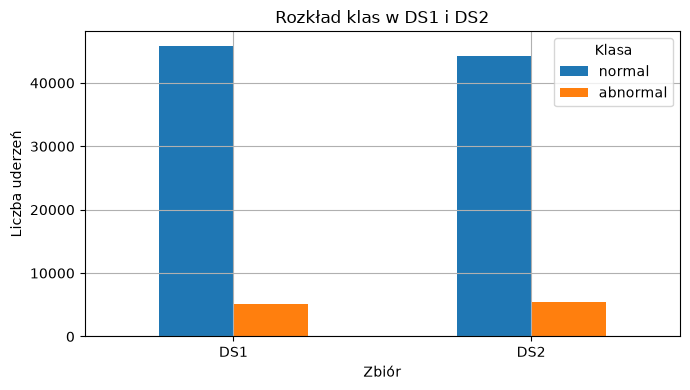

In [15]:
plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar", ax=plt.gca())
plt.title("Rozkład klas w DS1 i DS2")
plt.xlabel("Zbiór")
plt.ylabel("Liczba uderzeń")
plt.xticks(rotation=0)
plt.legend(title="Klasa")
plt.tight_layout()
plt.show()


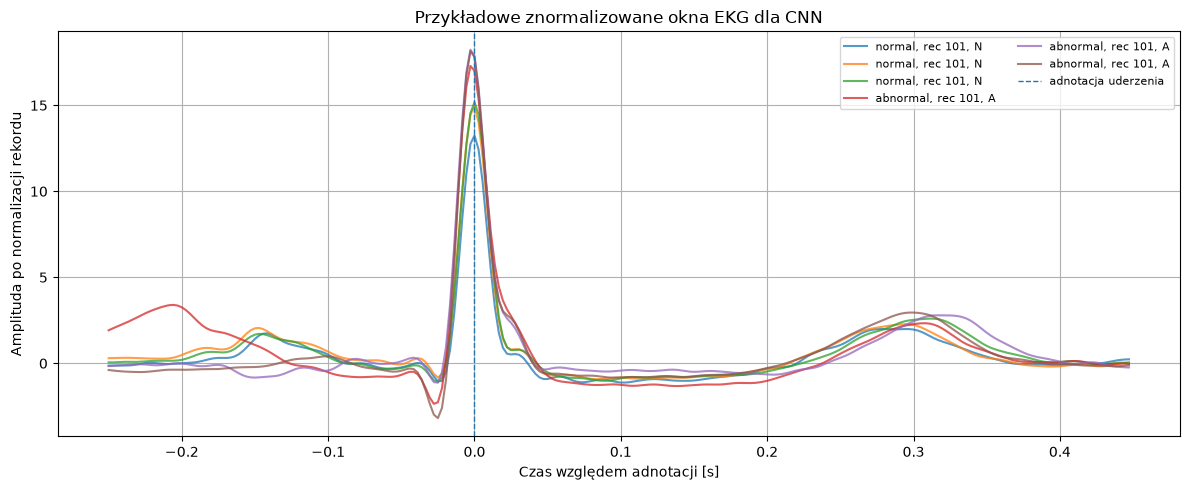

In [16]:
# Przykładowe okna sygnału dla klasy normal i abnormal.
example_indices = []
for label_int in [0, 1]:
    idx = np.where(y == label_int)[0]
    if len(idx) > 0:
        example_indices.extend(idx[:3])

plt.figure(figsize=(12, 5))
for idx in example_indices:
    label = INT_TO_LABEL[int(y[idx])]
    t = np.arange(X_windows.shape[1]) / meta_df.loc[idx, "fs"] - PRE_SEC
    plt.plot(t, X_windows[idx], alpha=0.75, label=f"{label}, rec {meta_df.loc[idx, 'record_id']}, {meta_df.loc[idx, 'symbol']}")

plt.axvline(0, linestyle="--", linewidth=1, label="adnotacja uderzenia")
plt.title("Przykładowe znormalizowane okna EKG dla CNN")
plt.xlabel("Czas względem adnotacji [s]")
plt.ylabel("Amplituda po normalizacji rekordu")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


### Przygotowanie macierzy cech

Z tabeli `features_df` usuwane są kolumny metadanych i etykiet. Pozostają tylko numeryczne cechy wejściowe dla modeli.

Ważne: imputacja braków i skalowanie są dopasowywane wyłącznie na zbiorze treningowym w ramach `Pipeline`. Dzięki temu unikamy przecieku informacji z walidacji lub testu.


In [17]:
METADATA_COLUMNS = {
    "record_id", "split", "sample", "time_sec", "symbol", "aami_class", "binary_class", "target",
    "fs", "channel_idx", "channel_name", "pre_sec", "post_sec",
    "record_median_after_filter", "record_iqr_after_filter",
}

feature_columns = [
    col for col in features_df.columns
    if col not in METADATA_COLUMNS and pd.api.types.is_numeric_dtype(features_df[col])
]

print("Liczba cech wejściowych:", len(feature_columns))
print(feature_columns[:30])

X_features = features_df[feature_columns].copy()
y_features = features_df["target"].to_numpy(dtype=int)
groups = features_df["record_id"].to_numpy()
splits = features_df["split"].to_numpy()


Liczba cech wejściowych: 54
['rr_prev_sec', 'rr_next_sec', 'rr_local_median_5', 'rr_local_median_10', 'rr_local_std_10', 'rr_ratio_prev_local_10', 'rr_diff_prev_next', 'hr_inst_bpm', 'win_mean', 'win_std', 'win_median', 'win_iqr', 'win_min', 'win_max', 'win_ptp', 'win_rms', 'win_energy', 'win_abs_area', 'win_skewness', 'win_kurtosis', 'r_amplitude', 'qrs_width_approx_sec', 'qrs_peak_abs', 'deriv_mean_abs', 'deriv_max_abs', 'line_length', 'baseline_shift_pre_post', 'total_power', 'bandpower_0_5_5', 'bandpower_5_15']


### Podział DS1 na trening i walidację

Finalny test to DS2. Z DS1 wydzielana jest walidacja po rekordach, nie po pojedynczych uderzeniach.

`StratifiedGroupKFold` zapewnia zachowanie rozkładu klas w zbiorze walidacyjnym i jednocześnie nie mieszanie rekordów.


In [18]:
ds1_mask = splits == "DS1"
ds2_mask = splits == "DS2"

ds1_indices = np.where(ds1_mask)[0]
ds2_indices = np.where(ds2_mask)[0]

X_ds1 = X_features.iloc[ds1_indices]
y_ds1 = y_features[ds1_indices]
groups_ds1 = groups[ds1_indices]

if HAS_STRATIFIED_GROUP_KFOLD:
    splitter = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    train_rel, val_rel = next(splitter.split(X_ds1, y_ds1, groups_ds1))
else:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
    train_rel, val_rel = next(splitter.split(X_ds1, y_ds1, groups_ds1))

train_indices = ds1_indices[train_rel]
val_indices = ds1_indices[val_rel]
test_indices = ds2_indices

print("Rekordy treningowe:", sorted(set(groups[train_indices])))
print("Rekordy walidacyjne:", sorted(set(groups[val_indices])))
print("Rekordy testowe DS2:", sorted(set(groups[test_indices])))

split_summary = pd.DataFrame({
    "subset": ["train", "validation", "test_DS2"],
    "n_beats": [len(train_indices), len(val_indices), len(test_indices)],
    "n_records": [len(set(groups[train_indices])), len(set(groups[val_indices])), len(set(groups[test_indices]))],
    "abnormal_fraction": [
        float(np.mean(y_features[train_indices])),
        float(np.mean(y_features[val_indices])),
        float(np.mean(y_features[test_indices])),
    ],
})
split_summary


Rekordy treningowe: [np.int64(101), np.int64(106), np.int64(108), np.int64(109), np.int64(112), np.int64(114), np.int64(115), np.int64(118), np.int64(119), np.int64(122), np.int64(203), np.int64(205), np.int64(207), np.int64(209), np.int64(223), np.int64(230)]
Rekordy walidacyjne: [np.int64(116), np.int64(124), np.int64(201), np.int64(208), np.int64(215), np.int64(220)]
Rekordy testowe DS2: [np.int64(100), np.int64(103), np.int64(105), np.int64(111), np.int64(113), np.int64(117), np.int64(121), np.int64(123), np.int64(200), np.int64(202), np.int64(210), np.int64(212), np.int64(213), np.int64(214), np.int64(219), np.int64(221), np.int64(222), np.int64(228), np.int64(231), np.int64(232), np.int64(233), np.int64(234)]


,subset,n_beats,n_records,abnormal_fraction
0,train,36643,16,0.081789
1,validation,14351,6,0.149746
2,test_DS2,49685,22,0.109590


## Funkcje ewaluacyjne

W projekcie biomedycznym sama `accuracy` nie wystarcza. Przy niezbalansowanych klasach model może mieć wysoką accuracy, przewidując głównie klasę normalną.

Raportowane są:

- `sensitivity` / `recall_abnormal` - ile nieprawidłowych uderzeń wykryto,
- `specificity` - ile prawidłowych uderzeń poprawnie uznano za prawidłowe,
- `precision_abnormal` - jaka część alarmów była faktycznie nieprawidłowa,
- `F1_abnormal`,
- `balanced_accuracy`,
- `ROC-AUC`,
- `PR-AUC`, szczególnie ważne przy niezbalansowanych danych.


In [19]:
def choose_decision_threshold(
    y_true: np.ndarray,
    y_score: np.ndarray,
    objective: str = THRESHOLD_OBJECTIVE,
    min_sensitivity: float = MIN_SENSITIVITY_FOR_THRESHOLD,
) -> float:
    """Dobiera próg na podstawie walidacji."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5

    precision_t = precision[:-1]
    recall_t = recall[:-1]
    f1_t = 2 * precision_t * recall_t / np.maximum(precision_t + recall_t, 1e-12)

    if objective == "high_sensitivity":
        eligible = np.where(recall_t >= min_sensitivity)[0]
        if len(eligible) > 0:
            # Wśród progów osiągających minimalną czułość wybieramy najlepsze F1.
            best_local = eligible[np.argmax(f1_t[eligible])]
            return float(thresholds[best_local])

    best_idx = int(np.nanargmax(f1_t))
    return float(thresholds[best_idx])


def evaluate_binary_classifier(
    y_true: np.ndarray,
    y_score: np.ndarray,
    threshold: float,
    model_name: str,
    subset_name: str,
) -> dict[str, float | str]:
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "model": model_name,
        "subset": subset_name,
        "threshold": float(threshold),
        "n": int(len(y_true)),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_abnormal": precision_score(y_true, y_pred, zero_division=0),
        "recall_abnormal_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity_normal": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1_abnormal": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
        metrics["pr_auc"] = average_precision_score(y_true, y_score)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics


def get_positive_scores(model, X):
    """Zwraca score/probability dla klasy abnormal=1."""
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] == 1:
            return np.zeros(len(X), dtype=float)
        return proba[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # Zamiana score na zakres 0-1 tylko do wyboru progu i metryk rankingowych.
        return 1.0 / (1.0 + np.exp(-scores))
    return model.predict(X).astype(float)


def plot_confusion_matrix_from_scores(y_true, y_score, threshold, title):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xticks([0, 1], ["normal", "abnormal"])
    plt.yticks([0, 1], ["normal", "abnormal"])
    plt.xlabel("Predykcja")
    plt.ylabel("Prawda")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


## Klasyczne uczenie maszynowe na cechach

W tym podejściu model nie dostaje surowego sygnału. Najpierw sygnał jest przekształcany do tabeli cech. Każdy wiersz odpowiada jednemu uderzeniu serca.

Zalety tego podejścia:

- wysoka interpretowalność,
- możliwość powiązania cech z fizjologią EKG,
- mniejsze wymagania obliczeniowe niż deep learning,
- dobry punkt odniesienia dla CNN.

Ograniczenia:

- wynik zależy od jakości zaprojektowanych cech,
- model może nie uchwycić złożonych wzorców morfologicznych,
- cechy są liczone wokół adnotowanych uderzeń, więc nie rozwiązujemy pełnego problemu detekcji QRS od zera.

### Modele klasycznego uczenia maszynowego

Trenowane są trzy modele:

1. **Dummy classifier** - punkt odniesienia. Pokazuje, ile daje samo zgadywanie klasy większościowej.
2. **Logistic Regression** - model liniowy, interpretowalny, dobry jako silny baseline.
3. **Random Forest** - model nieliniowy, który potrafi uchwycić interakcje między cechami.

Dla modeli używane są wagi klas, ponieważ liczba uderzeń normalnych i nieprawidłowych jest niezbalansowana.


In [20]:
X_train_feat = X_features.iloc[train_indices]
y_train = y_features[train_indices]
X_val_feat = X_features.iloc[val_indices]
y_val = y_features[val_indices]
X_test_feat = X_features.iloc[test_indices]
y_test = y_features[test_indices]

ml_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=None,
        )),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

ml_results = []
trained_ml_models = {}
ml_thresholds = {}

for name, model in ml_models.items():
    print("\n" + "=" * 80)
    print("Trenowanie modelu:", name)
    print("=" * 80)

    model.fit(X_train_feat, y_train)
    trained_ml_models[name] = model

    val_scores = get_positive_scores(model, X_val_feat)
    if name == "dummy_most_frequent":
        threshold = 0.5
    else:
        threshold = choose_decision_threshold(y_val, val_scores)
    ml_thresholds[name] = threshold

    test_scores = get_positive_scores(model, X_test_feat)

    val_metrics = evaluate_binary_classifier(y_val, val_scores, threshold, name, "validation")
    test_metrics = evaluate_binary_classifier(y_test, test_scores, threshold, name, "test_DS2")

    ml_results.extend([val_metrics, test_metrics])

    print("Próg decyzyjny:", threshold)
    print("Walidacja:")
    print(classification_report(y_val, (val_scores >= threshold).astype(int), target_names=["normal", "abnormal"], zero_division=0))
    print("Test DS2:")
    print(classification_report(y_test, (test_scores >= threshold).astype(int), target_names=["normal", "abnormal"], zero_division=0))

    if HAS_JOBLIB:
        joblib.dump(model, OUTPUT_DIR / f"model_ml_{name}.joblib")

ml_metrics_df = pd.DataFrame(ml_results)
ml_metrics_df.to_csv(OUTPUT_DIR / "metrics_ml.csv", index=False)
ml_metrics_df



Trenowanie modelu: dummy_most_frequent
Próg decyzyjny: 0.5
Walidacja:
              precision    recall  f1-score   support

      normal       0.85      1.00      0.92     12202
    abnormal       0.00      0.00      0.00      2149

    accuracy                           0.85     14351
   macro avg       0.43      0.50      0.46     14351
weighted avg       0.72      0.85      0.78     14351

Test DS2:
              precision    recall  f1-score   support

      normal       0.89      1.00      0.94     44240
    abnormal       0.00      0.00      0.00      5445

    accuracy                           0.89     49685
   macro avg       0.45      0.50      0.47     49685
weighted avg       0.79      0.89      0.84     49685


Trenowanie modelu: logistic_regression
Próg decyzyjny: 0.9785835566319596
Walidacja:
              precision    recall  f1-score   support

      normal       0.95      0.99      0.97     12202
    abnormal       0.91      0.71      0.80      2149

    accuracy   

,model,subset,threshold,n,accuracy,balanced_accuracy,precision_abnormal,recall_abnormal_sensitivity,specificity_normal,f1_abnormal,tn,fp,fn,tp,roc_auc,pr_auc
0,dummy_most_frequent,validation,0.500000,14351,0.850254,0.500000,0.000000,0.000000,1.000000,0.000000,12202,0,2149,0,0.500000,0.149746
1,dummy_most_frequent,test_DS2,0.500000,49685,0.890410,0.500000,0.000000,0.000000,1.000000,0.000000,44240,0,5445,0,0.500000,0.109590
2,logistic_regression,validation,0.978584,14351,0.946833,0.850846,0.912010,0.713820,0.987871,0.800835,12054,148,615,1534,0.931782,0.840595
3,logistic_regression,test_DS2,0.978584,49685,0.930724,0.747062,0.780454,0.511846,0.982278,0.618234,43456,784,2658,2787,0.883707,0.674634
4,random_forest,validation,0.341863,14351,0.950317,0.884907,0.865209,0.791531,0.978282,0.826731,11937,265,448,1701,0.964595,0.898519
5,random_forest,test_DS2,0.341863,49685,0.883003,0.802562,0.476960,0.699541,0.905583,0.567195,40063,4177,1636,3809,0.843894,0.696116


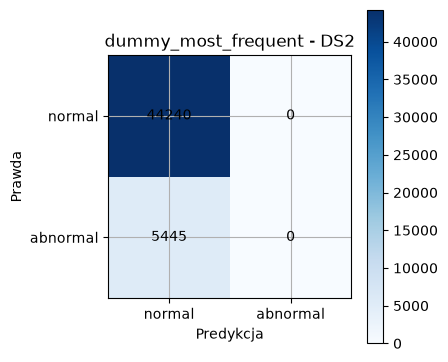

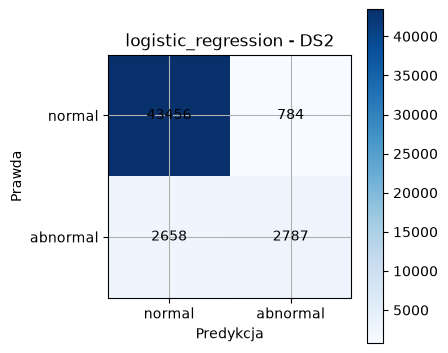

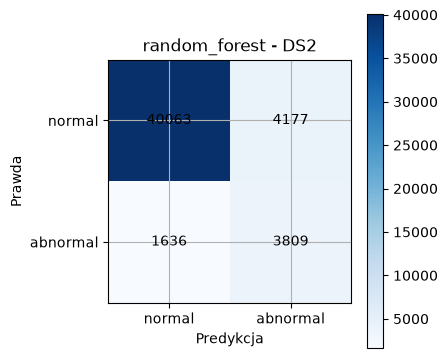

In [21]:
# Macierze pomyłek dla modeli klasycznych na DS2.
for name, model in trained_ml_models.items():
    scores = get_positive_scores(model, X_test_feat)
    plot_confusion_matrix_from_scores(
        y_test,
        scores,
        ml_thresholds[name],
        title=f"{name} - DS2"
    )


### Interpretacja cech w modelach klasycznych

Dla podejścia klasycznego warto sprawdzić, które cechy były istotne. Nie należy jednak interpretować ich jako bezpośredniego dowodu medycznego. Są to cechy statystyczne powiązane z predykcją modelu.

Dla regresji logistycznej analizujemy wartość bezwzględną współczynników po skalowaniu. Dla Random Forest analizujemy `feature_importances_`.


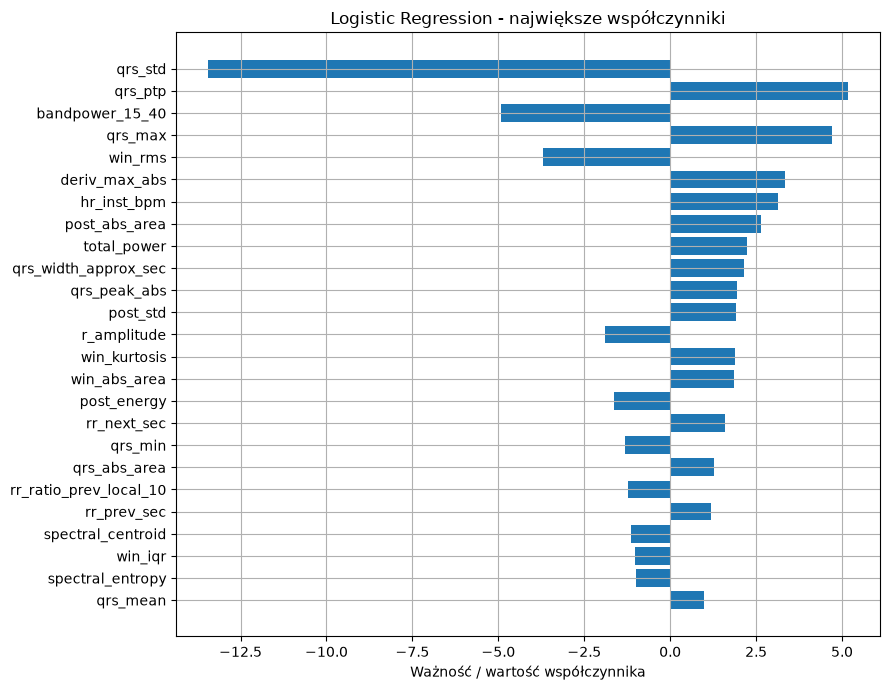

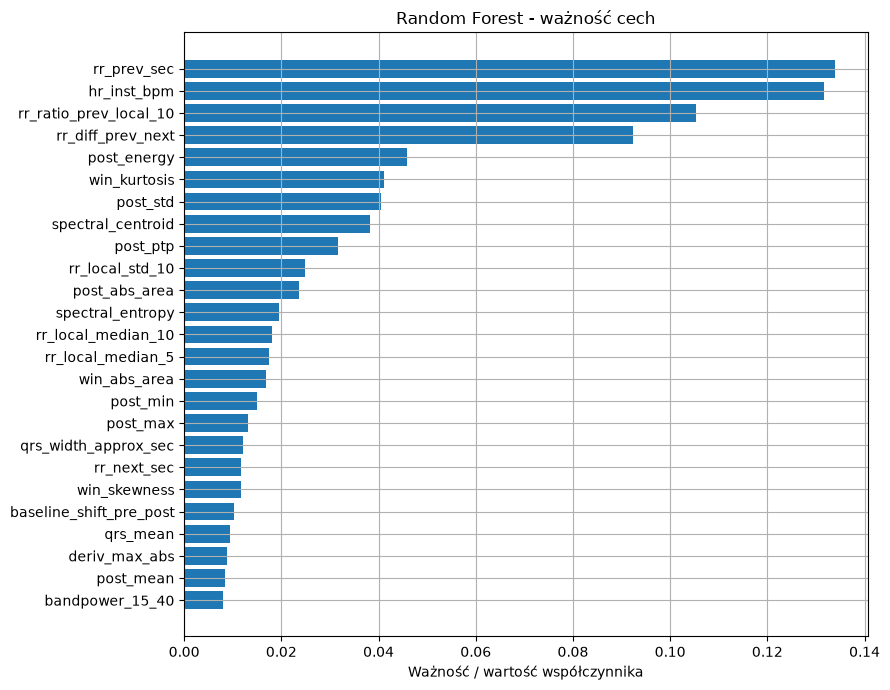

In [22]:
def plot_top_feature_importances(importances: np.ndarray, feature_names: list[str], title: str, top_n: int = 25):
    order = np.argsort(np.abs(importances))[::-1][:top_n]
    selected_names = [feature_names[i] for i in order]
    selected_values = importances[order]

    plt.figure(figsize=(9, 7))
    plt.barh(range(len(selected_names)), selected_values[::-1])
    plt.yticks(range(len(selected_names)), selected_names[::-1])
    plt.title(title)
    plt.xlabel("Ważność / wartość współczynnika")
    plt.tight_layout()
    plt.show()

if "logistic_regression" in trained_ml_models:
    log_reg = trained_ml_models["logistic_regression"]
    coef = log_reg.named_steps["model"].coef_[0]
    plot_top_feature_importances(coef, feature_columns, "Logistic Regression - największe współczynniki", top_n=25)

if "random_forest" in trained_ml_models:
    rf = trained_ml_models["random_forest"]
    importances = rf.named_steps["model"].feature_importances_
    plot_top_feature_importances(importances, feature_columns, "Random Forest - ważność cech", top_n=25)


### Analiza błędów

W projektach biomedycznych ważne jest nie tylko podanie metryk, ale też sprawdzenie, jakie przypadki model myli.

Poniżej analizowane są:

- **FP** - normalne uderzenia błędnie oznaczone jako abnormal,
- **FN** - nieprawidłowe uderzenia błędnie oznaczone jako normal.

Fałszywie ujemne wyniki są szczególnie istotne, ponieważ oznaczają przeoczenie nieprawidłowego uderzenia.


In [23]:
# Wybieramy najlepszy model klasyczny na podstawie F1 na walidacji.
val_ml = ml_metrics_df[ml_metrics_df["subset"] == "validation"].copy()
best_ml_name = val_ml.sort_values("f1_abnormal", ascending=False).iloc[0]["model"]
best_ml_model = trained_ml_models[best_ml_name]
best_ml_threshold = ml_thresholds[best_ml_name]

print("Najlepszy model klasyczny wg F1 na walidacji:", best_ml_name)

best_test_scores = get_positive_scores(best_ml_model, X_test_feat)
best_test_pred = (best_test_scores >= best_ml_threshold).astype(int)

test_meta = meta_df.iloc[test_indices].copy().reset_index(drop=True)
test_meta["y_true"] = y_test
test_meta["y_score"] = best_test_scores
test_meta["y_pred"] = best_test_pred
test_meta["error_type"] = "correct"
test_meta.loc[(test_meta["y_true"] == 0) & (test_meta["y_pred"] == 1), "error_type"] = "FP"
test_meta.loc[(test_meta["y_true"] == 1) & (test_meta["y_pred"] == 0), "error_type"] = "FN"

error_summary = (
    test_meta.groupby(["error_type", "aami_class", "symbol"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

error_summary.head(20)


Najlepszy model klasyczny wg F1 na walidacji: random_forest


,error_type,aami_class,symbol,count
0,correct,N,N,32430
1,FP,N,N,3998
2,correct,N,L,3960
3,correct,N,R,3461
4,correct,V,V,3127
5,FN,S,A,1466
6,correct,F,F,363
7,correct,S,A,270
8,correct,N,j,212
9,FP,N,L,164


## Deep learning na oknach sygnału

W tym podejściu model otrzymuje bezpośrednio okno sygnału EKG. Nie projektujemy ręcznie cech morfologicznych. Model ma sam nauczyć się filtrów wykrywających lokalne wzorce, np. kształt zespołu QRS, gwałtowne zmiany amplitudy lub niestandardową morfologię.

Najbardziej naturalnym modelem dla takiego zadania jest **1D CNN**, ponieważ:

- EKG jest sygnałem jednowymiarowym w czasie,
- konwolucje 1D wykrywają lokalne wzorce w krótkich fragmentach,
- kolejne warstwy mogą łączyć proste wzorce w bardziej złożone reprezentacje.

Wariant:

```text
okno EKG 252 × 1 → Conv1D → BatchNorm → ReLU → Pooling → GlobalAveragePooling → Dense → sigmoid
```

Wejściem do CNN są okna po filtracji i normalizacji rekordowej `median/IQR`. Taka normalizacja ogranicza wpływ różnic amplitudy między rekordami, ale nie usuwa całkowicie informacji o lokalnym kształcie uderzenia.


### Przygotowanie tensorów dla CNN

Tensor wejściowy ma kształt:

```text
liczba_próbek × długość_okna × liczba_kanałów
```

Używany jest jeden kanał, więc:

```text
X.shape = [n_beats, 252, 1]
```

Podział trening/walidacja/test jest identyczny jak w przypadku uczenia maszynowego, aby porównanie było uczciwe.


In [24]:
X_cnn = X_windows[..., np.newaxis].astype(np.float32)

X_train_cnn = X_cnn[train_indices]
y_train_cnn = y_features[train_indices]

X_val_cnn = X_cnn[val_indices]
y_val_cnn = y_features[val_indices]

X_test_cnn = X_cnn[test_indices]
y_test_cnn = y_features[test_indices]

print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn:", X_val_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)
print("Odsetek abnormal train/val/test:", np.mean(y_train_cnn), np.mean(y_val_cnn), np.mean(y_test_cnn))


X_train_cnn: (36643, 252, 1)
X_val_cnn: (14351, 252, 1)
X_test_cnn: (49685, 252, 1)
Odsetek abnormal train/val/test: 0.08178915481810987 0.14974566232318307 0.10959041964375565


### Architektura 1D CNN

Model jest celowo niewielki. MIT-BIH nie jest dużym zbiorem, więc bardzo głęboka sieć mogłaby łatwo dopasować się do specyfiki rekordów treningowych.

Elementy architektury:

- `Conv1D` - uczy lokalnych filtrów morfologicznych,
- `BatchNormalization` - stabilizuje uczenie,
- `ReLU` - nieliniowość,
- `MaxPooling1D` - redukcja długości sekwencji,
- `GlobalAveragePooling1D` - agregacja reprezentacji bez zbyt dużej liczby parametrów,
- `Dropout` - ograniczenie przeuczenia,
- `sigmoid` - prawdopodobieństwo klasy abnormal.


In [25]:
def build_cnn_1d(input_shape: tuple[int, int], learning_rate: float = CNN_LEARNING_RATE):
    if not HAS_TF:
        raise ImportError(
            "TensorFlow/Keras nie jest dostępny. Zainstaluj pakiet tensorflow."
        ) from TF_IMPORT_ERROR

    inputs = keras.Input(shape=input_shape, name="ecg_window")

    x = keras.layers.Conv1D(32, kernel_size=7, padding="same", use_bias=False)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)

    x = keras.layers.Conv1D(64, kernel_size=5, padding="same", use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)

    x = keras.layers.Conv1D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)

    x = keras.layers.Conv1D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)

    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(64, activation="relu")(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid", name="abnormal_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="ecg_1d_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )
    return model

if HAS_TF:
    cnn_model = build_cnn_1d(input_shape=X_train_cnn.shape[1:])
    cnn_model.summary()
else:
    print("TensorFlow nie jest dostępny - komórki treningu CNN zostaną pominięte do czasu instalacji.")


Model: "ecg_1d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_window (InputLayer)         │ (None, 252, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 252, 32)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 252, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 252, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 126, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 126, 64)        │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 126, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 63, 128)        │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 63, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 31, 128)        │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ abnormal_probability (Dense)    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,921 (366.88 KB)

 Trainable params: 93,217 (364.13 KB)

 Non-trainable params: 704 (2.75 KB)

### Trening CNN

Ze względu na niezbalansowanie klas używane są wagi klas. Model jest trenowany z:

- `EarlyStopping` - zatrzymanie, gdy jakość walidacyjna przestaje się poprawiać,
- `ReduceLROnPlateau` - zmniejszenie learning rate przy stagnacji,
- monitorowaniem `val_pr_auc`, ponieważ PR-AUC jest użyteczne przy niezbalansowanych danych.


In [26]:
cnn_history = None
cnn_metrics_df = pd.DataFrame()

if HAS_TF and RUN_DEEP_LEARNING:
    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train_cnn,
    )
    class_weight = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}
    print("Class weights:", class_weight)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=8,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
        ),
    ]

    cnn_history = cnn_model.fit(
        X_train_cnn,
        y_train_cnn,
        validation_data=(X_val_cnn, y_val_cnn),
        epochs=CNN_EPOCHS,
        batch_size=CNN_BATCH_SIZE,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    cnn_model.save(OUTPUT_DIR / "model_cnn_1d.keras")
else:
    print("Trening CNN pominięty. HAS_TF=", HAS_TF, "RUN_DEEP_LEARNING=", RUN_DEEP_LEARNING)


Class weights: {0: 0.5445372406823991, 1: 6.11327994661328}
Epoch 1/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 48s 267ms/step - accuracy: 0.9062 - loss: 0.3285 - pr_auc: 0.7503 - roc_auc: 0.9350 - val_accuracy: 0.9447 - val_loss: 0.3390 - val_pr_auc: 0.8394 - val_roc_auc: 0.9135 - learning_rate: 0.0010
Epoch 2/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 33s 232ms/step - accuracy: 0.9463 - loss: 0.1917 - pr_auc: 0.8758 - roc_auc: 0.9778 - val_accuracy: 0.9042 - val_loss: 0.2813 - val_pr_auc: 0.8243 - val_roc_auc: 0.9005 - learning_rate: 0.0010
Epoch 3/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 35s 244ms/step - accuracy: 0.9598 - loss: 0.1472 - pr_auc: 0.9063 - roc_auc: 0.9856 - val_accuracy: 0.9241 - val_loss: 0.2842 - val_pr_auc: 0.8210 - val_roc_auc: 0.8994 - learning_rate: 0.0010
Epoch 4/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 37s 256ms/step - accuracy: 0.9673 - loss: 0.1212 - pr_auc: 0.9305 - roc_auc: 0.9902 - val_accuracy: 0.9082 - val_loss: 0.3018 - val_pr_auc: 0.8150 - val_roc_auc: 0.9021 - learning_rate: 0.0010
Epoch 5/

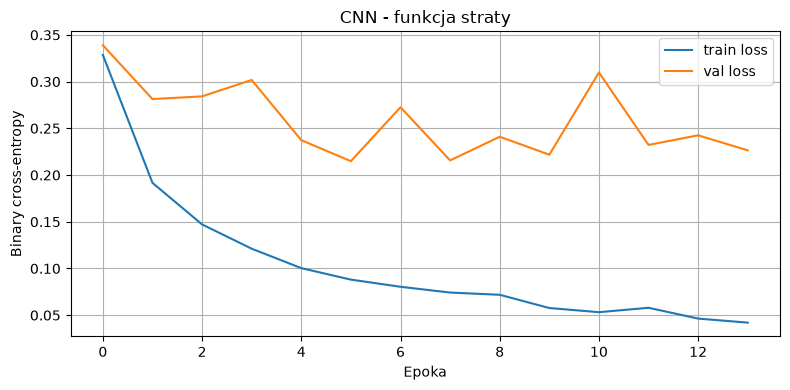

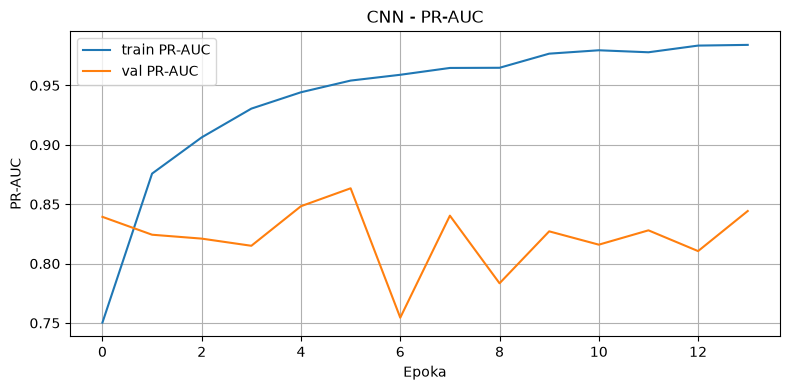

In [27]:
if cnn_history is not None:
    history_df = pd.DataFrame(cnn_history.history)
    history_df.to_csv(OUTPUT_DIR / "history_cnn.csv", index=False)

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["loss"], label="train loss")
    plt.plot(history_df["val_loss"], label="val loss")
    plt.title("CNN - funkcja straty")
    plt.xlabel("Epoka")
    plt.ylabel("Binary cross-entropy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "pr_auc" in history_df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(history_df["pr_auc"], label="train PR-AUC")
        plt.plot(history_df["val_pr_auc"], label="val PR-AUC")
        plt.title("CNN - PR-AUC")
        plt.xlabel("Epoka")
        plt.ylabel("PR-AUC")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Brak historii treningu CNN do wyświetlenia.")


### Ewaluacja CNN na walidacji i DS2

Próg klasyfikacji dla CNN jest dobierany na zbiorze walidacyjnym, a następnie bez zmian stosowany do testu DS2.


57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step
195/195 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step
Próg CNN: 0.15215086936950684
Walidacja CNN:
              precision    recall  f1-score   support

      normal       0.96      0.98      0.97     12202
    abnormal       0.87      0.77      0.82      2149

    accuracy                           0.95     14351
   macro avg       0.92      0.88      0.90     14351
weighted avg       0.95      0.95      0.95     14351

Test DS2 CNN:
              precision    recall  f1-score   support

      normal       0.97      0.81      0.88     44240
    abnormal       0.33      0.78      0.47      5445

    accuracy                           0.80     49685
   macro avg       0.65      0.79      0.67     49685
weighted avg       0.90      0.80      0.84     49685



,model,subset,threshold,n,accuracy,balanced_accuracy,precision_abnormal,recall_abnormal_sensitivity,specificity_normal,f1_abnormal,tn,fp,fn,tp,roc_auc,pr_auc
0,cnn_1d,validation,0.152151,14351,0.949202,0.876967,0.872508,0.773848,0.980085,0.820222,11959,243,486,1663,0.929729,0.863472
1,cnn_1d,test_DS2,0.152151,49685,0.804770,0.792532,0.332678,0.776860,0.808205,0.465859,35755,8485,1215,4230,0.885762,0.578025


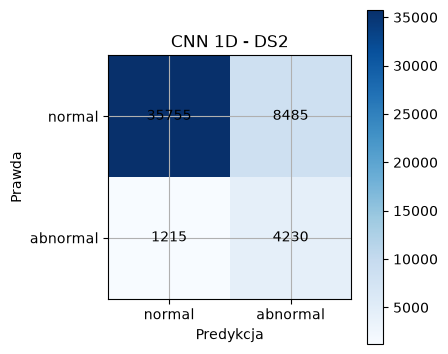

In [28]:
if HAS_TF and RUN_DEEP_LEARNING and 'cnn_model' in globals() and cnn_history is not None:
    val_scores_cnn = cnn_model.predict(X_val_cnn, batch_size=CNN_BATCH_SIZE).ravel()
    cnn_threshold = choose_decision_threshold(y_val_cnn, val_scores_cnn)

    test_scores_cnn = cnn_model.predict(X_test_cnn, batch_size=CNN_BATCH_SIZE).ravel()

    cnn_val_metrics = evaluate_binary_classifier(
        y_val_cnn, val_scores_cnn, cnn_threshold, "cnn_1d", "validation"
    )
    cnn_test_metrics = evaluate_binary_classifier(
        y_test_cnn, test_scores_cnn, cnn_threshold, "cnn_1d", "test_DS2"
    )

    cnn_metrics_df = pd.DataFrame([cnn_val_metrics, cnn_test_metrics])
    cnn_metrics_df.to_csv(OUTPUT_DIR / "metrics_cnn.csv", index=False)

    print("Próg CNN:", cnn_threshold)
    print("Walidacja CNN:")
    print(classification_report(y_val_cnn, (val_scores_cnn >= cnn_threshold).astype(int), target_names=["normal", "abnormal"], zero_division=0))
    print("Test DS2 CNN:")
    print(classification_report(y_test_cnn, (test_scores_cnn >= cnn_threshold).astype(int), target_names=["normal", "abnormal"], zero_division=0))

    display(cnn_metrics_df)

    plot_confusion_matrix_from_scores(y_test_cnn, test_scores_cnn, cnn_threshold, "CNN 1D - DS2")
else:
    print("CNN nie został wytrenowany w tym uruchomieniu.")


## Analiza błędów

Tak jak dla modelu klasycznego, warto obejrzeć przypadki fałszywie dodatnie i fałszywie ujemne. Oglądanie sygnałów jest ważne, bo pozwala ocenić, czy model myli się na trudnych morfologiach, zakłóconych fragmentach, czy nietypowych rekordach.


Liczba FN: 1215
Liczba FP: 8485


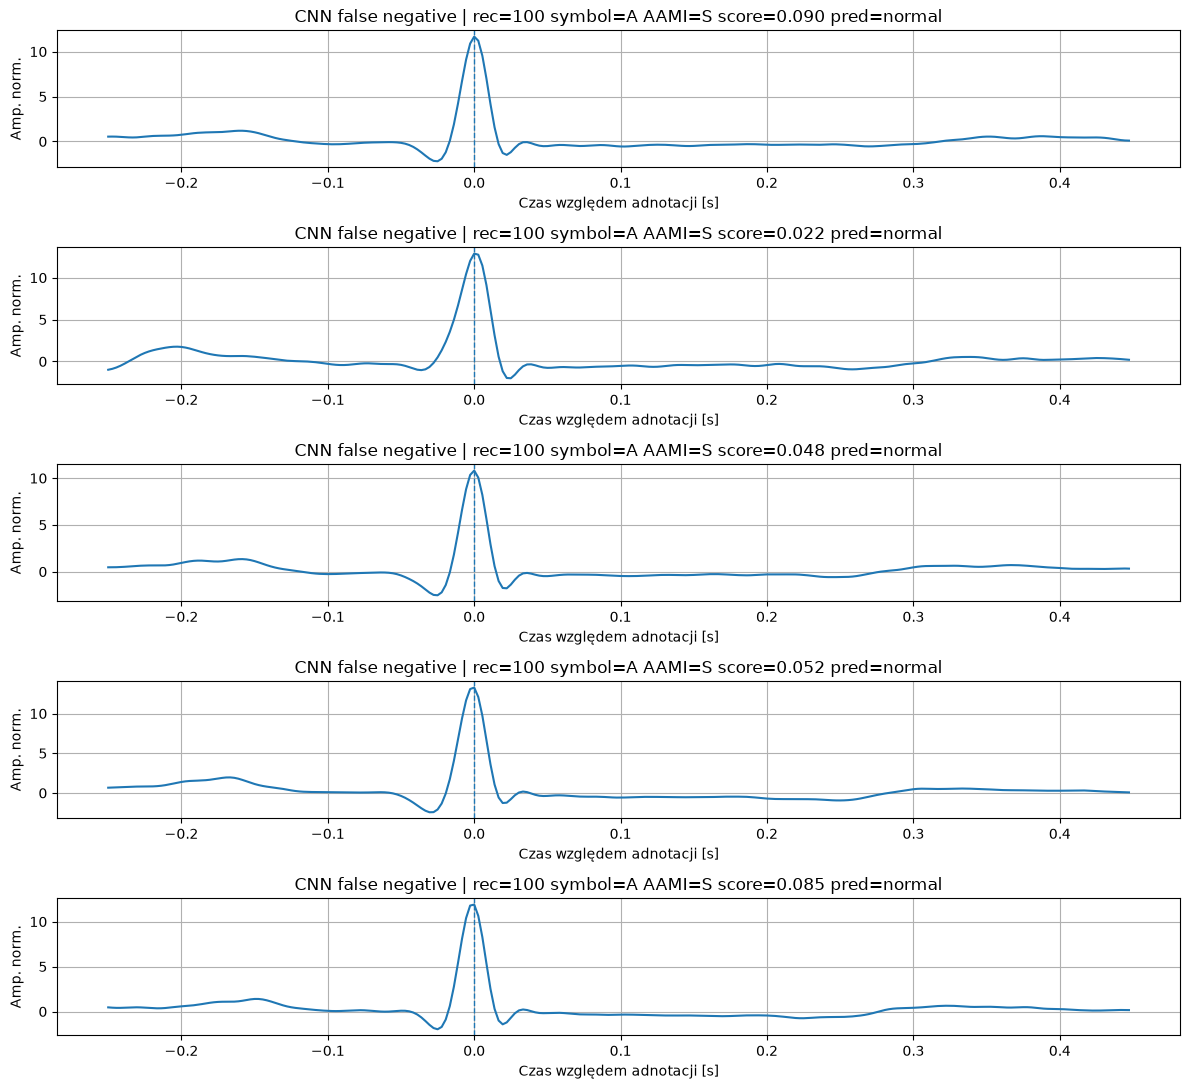

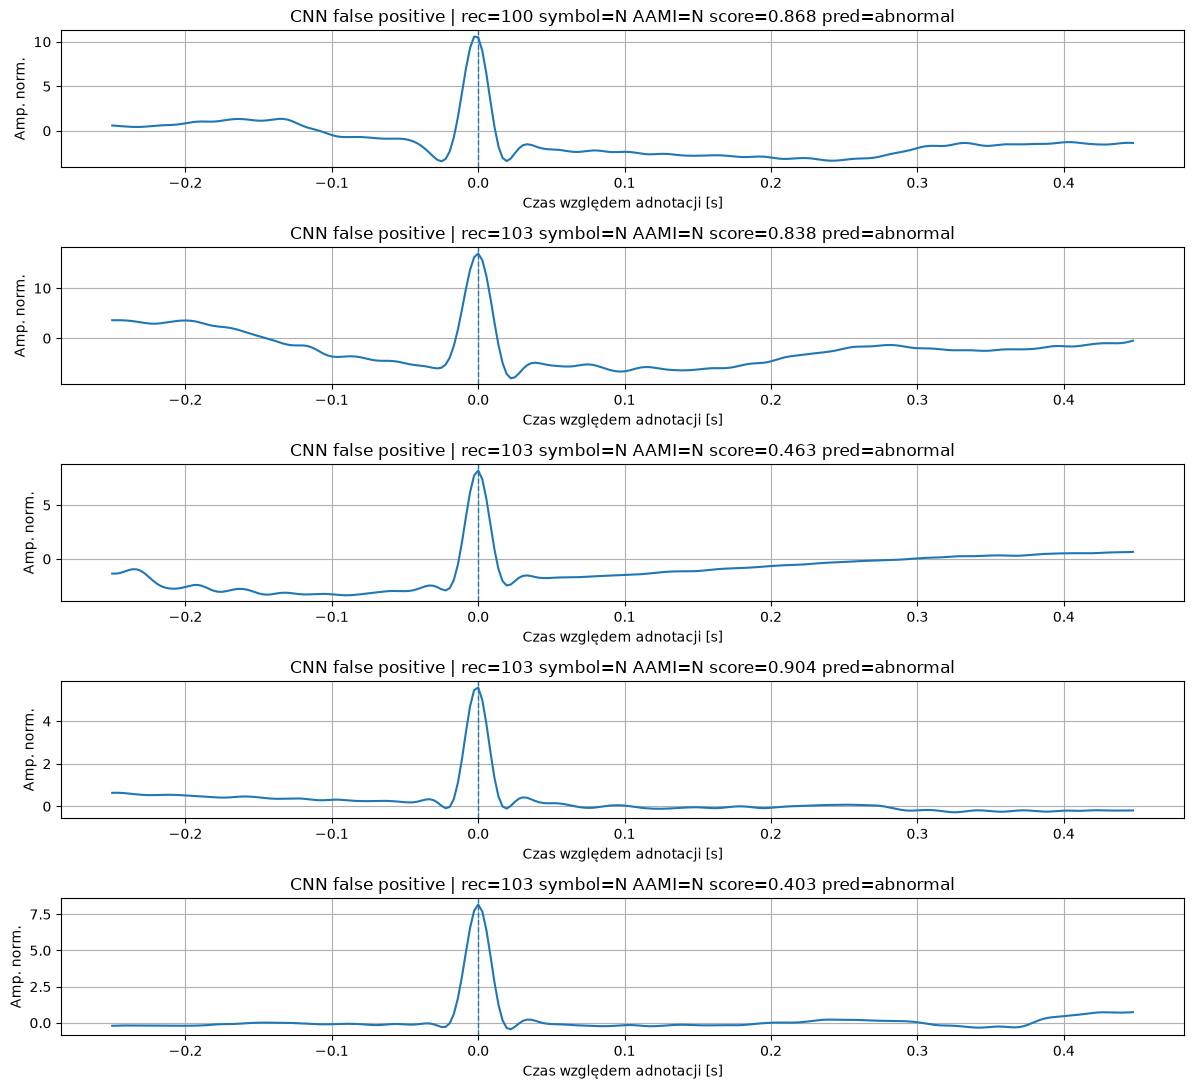

In [29]:
def plot_error_windows(global_indices: np.ndarray, scores: np.ndarray, preds: np.ndarray, title: str, max_examples: int = 6):
    selected = list(global_indices[:max_examples])
    if len(selected) == 0:
        print("Brak przykładów:", title)
        return

    plt.figure(figsize=(12, 2.2 * len(selected)))
    for plot_i, global_idx in enumerate(selected, start=1):
        ax = plt.subplot(len(selected), 1, plot_i)
        fs = float(meta_df.loc[global_idx, "fs"])
        t = np.arange(X_windows.shape[1]) / fs - PRE_SEC
        ax.plot(t, X_windows[global_idx])
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(
            f"{title} | rec={meta_df.loc[global_idx, 'record_id']} "
            f"symbol={meta_df.loc[global_idx, 'symbol']} "
            f"AAMI={meta_df.loc[global_idx, 'aami_class']} "
            f"score={scores[np.where(test_indices == global_idx)[0][0]]:.3f} "
            f"pred={INT_TO_LABEL[int(preds[np.where(test_indices == global_idx)[0][0]])]}"
        )
        ax.set_xlabel("Czas względem adnotacji [s]")
        ax.set_ylabel("Amp. norm.")
    plt.tight_layout()
    plt.show()

if HAS_TF and RUN_DEEP_LEARNING and 'test_scores_cnn' in globals():
    cnn_pred_test = (test_scores_cnn >= cnn_threshold).astype(int)
    fn_global = test_indices[(y_test_cnn == 1) & (cnn_pred_test == 0)]
    fp_global = test_indices[(y_test_cnn == 0) & (cnn_pred_test == 1)]

    print("Liczba FN:", len(fn_global))
    print("Liczba FP:", len(fp_global))

    plot_error_windows(fn_global, test_scores_cnn, cnn_pred_test, "CNN false negative", max_examples=5)
    plot_error_windows(fp_global, test_scores_cnn, cnn_pred_test, "CNN false positive", max_examples=5)
else:
    print("Brak predykcji CNN do analizy błędów.")


## Porównanie wyników klasycznego ML i deep learning

Wyniki pokazują, że oba podejścia  mają różny profil błędów. Modele klasycznego uczenia maszynowego, szczególnie regresja logistyczna i Random Forest, osiągnęły stabilniejsze wyniki na zbiorze testowym DS2. 

- **Regresja logistyczna** uzyskała najwyższą accuracy, najwyższą precision dla klasy `abnormal` oraz najwyższy `F1-score` dla klasy `abnormal`. Oznacza to, że model ten generował stosunkowo mało fałszywych alarmów, ale jednocześnie przeoczył większą część rzeczywistych nieprawidłowych uderzeń niż Random Forest i CNN.

- **Random Forest** uzyskał najlepszy kompromis między czułością i swoistością. Jego `balanced accuracy` była najwyższa spośród modeli z drugiej części projektu, a `recall` dla klasy `abnormal` był wyraźnie wyższy niż w regresji logistycznej. Model ten wykrywał więcej nieprawidłowych uderzeń, ale kosztem większej liczby fałszywych alarmów. Jest to oczekiwane, ponieważ model nieliniowy może lepiej wykorzystywać zależności między cechami rytmu, morfologii i jakości sygnału.

- **Model CNN** osiągnął najwyższą czułość dla klasy `abnormal`. Na DS2 wykrył największą liczbę nieprawidłowych uderzeń, czyli miał najmniej wyników fałszywie ujemnych. Jednocześnie miał najniższą `precision` dla klasy abnormal, ponieważ oznaczył jako nieprawidłowe wiele uderzeń prawidłowych. W praktyce oznacza to, że CNN w tej konfiguracji działa bardziej jak model "ostrożny klinicznie" pod względem wykrywania arytmii, ale zbyt często generuje alarmy. Spadek jakości między walidacją a DS2 wskazuje również, że model głęboki gorzej uogólnił się na niezależne rekordy pacjentów niż modele klasyczne.

In [30]:
all_metrics = [ml_metrics_df]
if isinstance(cnn_metrics_df, pd.DataFrame) and not cnn_metrics_df.empty:
    all_metrics.append(cnn_metrics_df)

comparison_df = pd.concat(all_metrics, ignore_index=True)
comparison_df = comparison_df.sort_values(["subset", "f1_abnormal"], ascending=[True, False])
comparison_df.to_csv(OUTPUT_DIR / "metrics_comparison.csv", index=False)
comparison_df


,model,subset,threshold,n,accuracy,balanced_accuracy,precision_abnormal,recall_abnormal_sensitivity,specificity_normal,f1_abnormal,tn,fp,fn,tp,roc_auc,pr_auc
3,logistic_regression,test_DS2,0.978584,49685,0.930724,0.747062,0.780454,0.511846,0.982278,0.618234,43456,784,2658,2787,0.883707,0.674634
5,random_forest,test_DS2,0.341863,49685,0.883003,0.802562,0.476960,0.699541,0.905583,0.567195,40063,4177,1636,3809,0.843894,0.696116
7,cnn_1d,test_DS2,0.152151,49685,0.804770,0.792532,0.332678,0.776860,0.808205,0.465859,35755,8485,1215,4230,0.885762,0.578025
1,dummy_most_frequent,test_DS2,0.500000,49685,0.890410,0.500000,0.000000,0.000000,1.000000,0.000000,44240,0,5445,0,0.500000,0.109590
4,random_forest,validation,0.341863,14351,0.950317,0.884907,0.865209,0.791531,0.978282,0.826731,11937,265,448,1701,0.964595,0.898519
6,cnn_1d,validation,0.152151,14351,0.949202,0.876967,0.872508,0.773848,0.980085,0.820222,11959,243,486,1663,0.929729,0.863472
2,logistic_regression,validation,0.978584,14351,0.946833,0.850846,0.912010,0.713820,0.987871,0.800835,12054,148,615,1534,0.931782,0.840595
0,dummy_most_frequent,validation,0.500000,14351,0.850254,0.500000,0.000000,0.000000,1.000000,0.000000,12202,0,2149,0,0.500000,0.149746


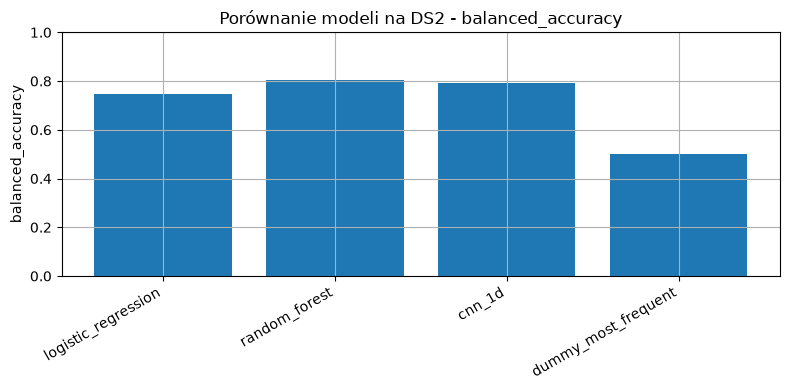

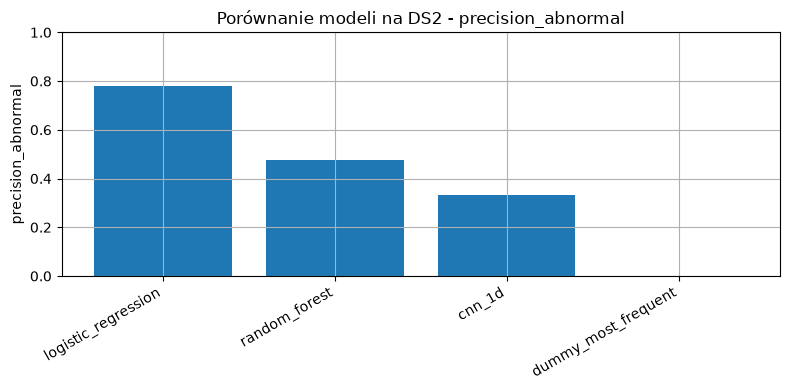

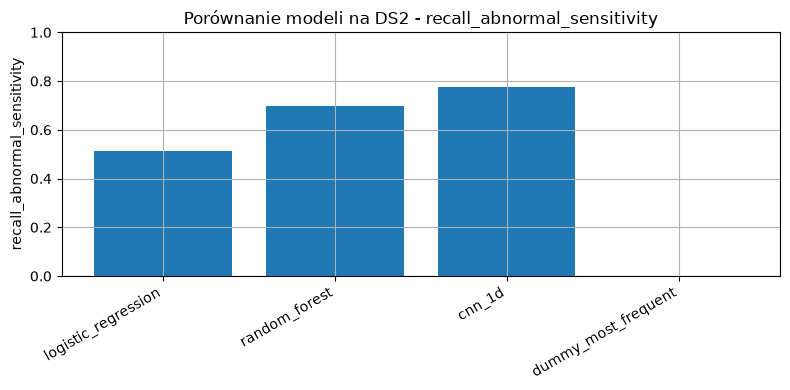

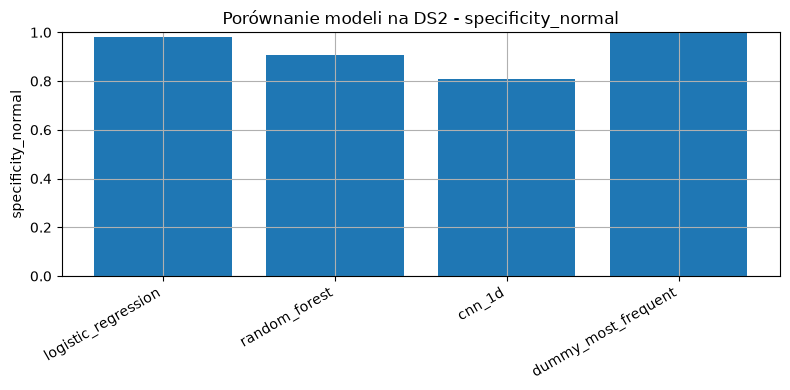

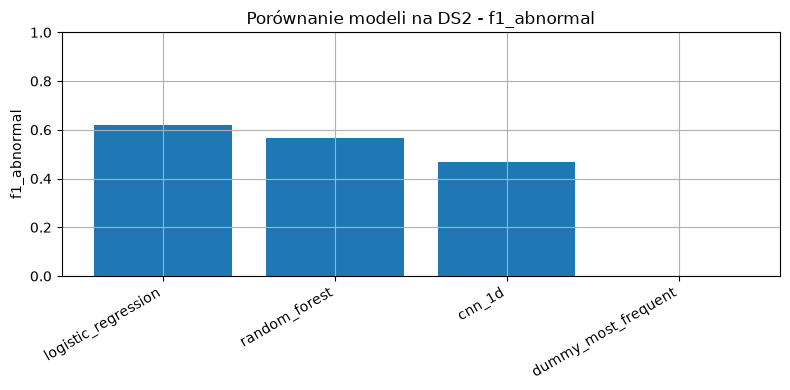

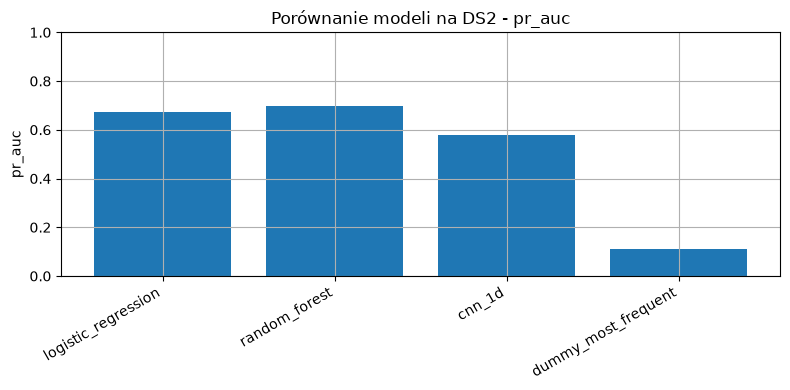

In [31]:
test_comparison = comparison_df[comparison_df["subset"] == "test_DS2"].copy()
metrics_to_plot = ["balanced_accuracy", "precision_abnormal", "recall_abnormal_sensitivity", "specificity_normal", "f1_abnormal", "pr_auc"]

for metric in metrics_to_plot:
    if metric in test_comparison.columns:
        plt.figure(figsize=(8, 4))
        plt.bar(test_comparison["model"], test_comparison[metric])
        plt.title(f"Porównanie modeli na DS2 - {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=30, ha="right")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()


Deep learning nie okazał się automatycznie lepszy od klasycznych metod. Dla tego zbioru danych, liczby próbek i przy zastosowanej architekturze, ręcznie zaprojektowane cechy okazały się bardzo konkurencyjne. Klasyczne ML lepiej kontrolowało liczbę fałszywych alarmów, natomiast CNN lepiej maksymalizowało wykrywalność nieprawidłowych uderzeń.

## Zestawienie wyników i wnioski końcowe

W projekcie porównano dwa podejścia do klasyfikacji nieprawidłowych uderzeń serca w zapisie EKG:

1. Podejście I - analiza odstępów RR
    Prosty, interpretowalny baseline oparty wyłącznie na informacji o rytmie serca.
2. Podejście II - klasyfikacja ML i DL
    Podejście wykorzystujące bogatszą reprezentację sygnału:
   - klasyczne uczenie maszynowe na ręcznie zaprojektowanych cechach,
   - model deep learning CNN 1D uczący się bezpośrednio z okien sygnału EKG.

Wszystkie modele oceniono na niezależnym zbiorze testowym DS2. Jest to istotne, ponieważ taki podział ogranicza ryzyko przecieku informacji między rekordami pacjentów i pozwala sprawdzić, jak modele generalizują na nowe zapisy EKG.

| Model                   | Accuracy | Balanced accuracy | Precision abnormal | Recall abnormal | Specificity | F1 abnormal | PR-AUC |
| ----------------------- | -------: | ----------------: | -----------------: | --------------: | ----------: | ----------: | -----: |
| Analiza odstępów RR             |   0.8726 |            0.7553 |             0.4410 |          0.6050 |      0.9055 |      0.5102 |      - |
| Regresja logistyczna |   0.9307 |            0.7471 |             0.7805 |          0.5118 |      0.9823 |      0.6182 | 0.6746 |
| Random Forest       |   0.8830 |            0.8026 |             0.4770 |          0.6995 |      0.9056 |      0.5672 | 0.6961 |
| Deep learning             |   0.8048 |            0.7925 |             0.3327 |          0.7769 |      0.8082 |      0.4659 | 0.5780 |
| Dummy most frequent |   0.8904 |            0.5000 |             0.0000 |          0.0000 |      1.0000 |      0.0000 | 0.1096 |

### Obserwacje

> **Sama accuracy nie wystarcza do oceny modeli.**
> 
> Model `Dummy most frequent` osiąga `accuracy` równą **0.8904**, ale nie wykrywa żadnego nieprawidłowego uderzenia.

Dlatego w tym problemie większe znaczenie mają metryki związane z klasą abnormal:

- `recall abnormal` - ile rzeczywistych nieprawidłowych uderzeń model wykrył,
- `precision abnormal` - jak często alarm modelu był trafny,
- `F1 abnormal` - kompromis między precision i recall,
- `balanced accuracy` - średnia jakość rozpoznawania obu klas,
- `PR-AUC` - jakość modelu przy różnych progach decyzyjnych, szczególnie ważna przy niezbalansowanych klasach.


### Analiza wyników

#### 1. Analiza odstępów RR

Podejście RR osiągnęło wynik lepszy niż uproszczony model dummy. Potwierdza to, że sama informacja o rytmie serca niesie istotną wartość diagnostyczną. 

Najważniejsze wyniki dla podejścia RR:

| Metryka | Wartość |
| ----------------------- | -------: |
| Accuracy | 0.8726 |
| Balanced accuracy | 0.7553 |
| Precision abnormal | 0.4410 |
| Recall abnormal | 0.6050 |
| F1 abnorma | 0.5102 |

Reguła RR wykrywała część nieprawidłowych uderzeń, szczególnie takich, które wyraźnie zaburzają rytm serca. Wynik recall `abnormal = 0.6050` oznacza, że metoda rozpoznała około 60% uderzeń nieprawidłowych.

Jednocześnie ograniczenie wyłącznie do odstępów RR jest istotną wadą tego podejścia. Reguła nie analizuje kształtu zespołu QRS ani innych cech morfologicznych sygnału. W konsekwencji może przeoczyć uderzenia, które występują w podobnym czasie jak uderzenia prawidłowe, ale różnią się kształtem.

#### 2. Klasyczne uczenie maszynowe

Klasyczne modele ML wykorzystywały szerszy zestaw cech opisujących zarówno rytm, jak i morfologię sygnału EKG. Dzięki temu mogły korzystać z informacji, której nie zawiera sama analiza RR.Takie podejście poprawiło jakość klasyfikacji względem reguły RR.

**Regresja logistyczna** uzyskała najlepsze wyniki pod względem:

- `accuracy = 0.9307`,
- `precision abnormal = 0.7805`,
- `specificity = 0.9823`,
- `F1 abnormal = 0.6182`.

Oznacza to, że model bardzo rzadko oznaczał uderzenia prawidłowe jako nieprawidłowe. Jego alarmy były najczęściej trafne, ale model był dość konserwatywny.

Niższy `recall abnormal = 0.5118` pokazuje, że regresja logistyczna przeoczyła część rzeczywistych nieprawidłowych uderzeń.

**Random Forest** uzyskał najlepsze wyniki pod względem:

- `balanced accuracy = 0.8026`,
- `PR-AUC = 0.6961`.

W porównaniu z regresją logistyczną model ten osiągnął wyższy `recall abnormal = 0.6995`, czyli wykrywał więcej nieprawidłowych uderzeń. Jednocześnie miał niższą precyzję, co oznacza większą liczbę fałszywych alarmów.

#### 3. Model deep learning (CNN 1D)

Model CNN 1D analizował bezpośrednio okna czasowe sygnału EKG. W przeciwieństwie do modeli ML nie wymagał ręcznego projektowania cech, ponieważ uczył się reprezentacji sygnału automatycznie.

CNN uzyskał najwyższy wynik:

- `recall abnormal = 0.7769`.

Oznacza to, że wykrył najwięcej rzeczywistych nieprawidłowych uderzeń spośród wszystkich porównywanych modeli.

Jednocześnie model miał niższą precyzję:

- `precision abnormal = 0.3327`.

W praktyce oznacza to, że CNN częściej oznaczał uderzenia prawidłowe jako nieprawidłowe. Model był więc najbardziej czuły, ale najmniej selektywny.

## Interpretacja biomedyczna wyników

Uzyskane wyniki są zgodne z fizjologiczną interpretacją sygnału EKG. Nieprawidłowe uderzenia mogą różnić się od uderzeń prawidłowych na dwa główne sposoby:

1. czasem wystąpienia, czyli zmianą odstępów RR,
2. morfologią, czyli kształtem zespołu QRS i przebiegiem sygnału w oknie wokół uderzenia.

Analiza odstępów RR dobrze opisuje zaburzenia związane z rytmem serca. Jeżeli uderzenie pojawia się przedwcześnie albo po nim występuje nietypowa przerwa, metoda RR może skutecznie wskazać potencjalną arytmię.

Nie wszystkie nieprawidłowe uderzenia powodują jednak wyraźną zmianę rytmu. Część z nich może występować w podobnych odstępach czasowych jak uderzenia prawidłowe, ale różnić się kształtem zespołu QRS. W takich przypadkach sama analiza RR jest niewystarczająca.

Dodanie cech morfologicznych poprawiło możliwości klasyfikacji. Cechy amplitudowe, energetyczne, pochodne oraz opis kształtu sygnału dostarczają informacji, której nie zawierają same odstępy RR.

Z biomedycznego punktu widzenia wyniki pokazują, że skuteczna klasyfikacja arytmii powinna uwzględniać jednocześnie:

- rytm pracy serca,
- lokalną zmienność odstępów RR,
- kształt zespołu QRS,
- amplitudę i energię sygnału,
- jakość analizowanego fragmentu EKG.

## Wnioski

Przeprowadzone eksperymenty pokazują, że klasyfikacja nieprawidłowych uderzeń serca w zapisie EKG wymaga uwzględnienia zarówno informacji o rytmie, jak i informacji o kształcie sygnału. Pierwsza część projektu, oparta na analizie odstępów RR, potwierdziła, że sam rytm serca niesie istotną informację diagnostyczną. Prosta reguła RR była w stanie wykryć część uderzeń nieprawidłowych i uzyskała wynik lepszy niż model większościowy. Jednocześnie jej skuteczność była ograniczona, ponieważ nie analizowała morfologii zespołu QRS.

Druga część projektu pokazała, że dodanie cech opisujących kształt, amplitudę, energię i lokalną dynamikę sygnału poprawia możliwości klasyfikacji. Modele klasycznego uczenia maszynowego osiągnęły najlepsze wyniki końcowe pod względem stabilności i jakości klasyfikacji. Regresja logistyczna była najbardziej precyzyjna, natomiast Random Forest najlepiej równoważył wykrywanie uderzeń prawidłowych i nieprawidłowych.

Model CNN 1D wykrył największą część rzeczywistych nieprawidłowych uderzeń. Odbyło się to jednak kosztem większej liczby fałszywych alarmów. Oznacza to, że deep learning dobrze rozpoznawał potencjalnie nietypowe fragmenty sygnału, ale w tej konfiguracji był mniej selektywny niż modele klasyczne.

Najważniejszy wniosek z całego projektu jest taki, że bardziej złożony model nie musi automatycznie oznaczać lepszego wyniku. Dla analizowanego problemu bardzo konkurencyjne okazało się klasyczne uczenie maszynowe na dobrze zaprojektowanych cechach biomedycznych. Deep learning ma potencjał, szczególnie w kontekście wykrywania większej liczby arytmii, ale wymaga dalszej kalibracji i lepszej kontroli fałszywych alarmów.

## Podsumowanie

W projekcie zaimplementowano kompletny pipeline klasyfikacji uderzeń serca na podstawie sygnału EKG z bazy MIT-BIH Arrhythmia Database. Dane zostały przetworzone z uwzględnieniem filtracji sygnału, segmentacji wokół adnotowanych uderzeń, mapowania symboli MIT-BIH do klas AAMI oraz binarnego podziału na klasy normal i abnormal.

W drugiej cześci projektu zrealizowane zostały dwa podejścia do klasyfikacji nieprawidłowych uderzeń EKG:

- **Podejście z klasycznym ML** wykorzystuje ręczne cechy rytmu, morfologii, widma i jakości sygnału, a następnie trenuje modele klasycznego uczenia maszynowego.
- **Podejście z DL** wykorzystuje okna sygnału EKG i model 1D CNN, który sam uczy się reprezentacji sygnału.

Najważniejsze elementy poprawności metodologicznej:

- zastosowano filtrację sygnału EKG przed ekstrakcją informacji,
- segmentacja jest oparta na adnotowanych uderzeniach,
- etykiety są mapowane do klas AAMI,
- podział danych jest wykonany po rekordach, a nie losowo po uderzeniach,
- próg decyzyjny jest dobierany na walidacji,
- test DS2 pozostaje niezależny,
- raportowane są metryki ważne dla problemów biomedycznych, nie tylko accuracy.

### Ograniczenia

Najważniejsze ograniczenia:

1. **Adnotowane uderzenia zamiast pełnej detekcji QRS.**  
   Notebook korzysta z referencyjnych pozycji uderzeń z MIT-BIH. W praktycznym systemie należałoby najpierw wykonać detekcję QRS.

2. **Jeden preferowany kanał.**  
   Główny wariant używa jednego kanału, zwykle `MLII`. Drugi kanał może zawierać dodatkowe informacje morfologiczne.

3. **Mały zbiór danych.**  
   MIT-BIH jest klasyczny i dobrze opisany, ale nie jest dużym współczesnym zbiorem wieloośrodkowym.

4. **Różnice między pacjentami.**  
   Nawet przy DS1/DS2 model może działać różnie dla różnych rekordów. Dlatego warto analizować wyniki per rekord.

5. **Brak walidacji klinicznej.**  
   Projekt ma charakter edukacyjno-badawczy. Nie może być traktowany jako narzędzie diagnostyczne.

6. **Klasa `Q`.**  
   Domyślnie jest pomijana. Jej włączenie powinno być opisane jako osobny eksperyment, ponieważ zmienia definicję problemu.


### Możliwe rozszerzenia

Dalsze prace, które zwiększyłyby wartość projektu:

1. **Model CNN + cechy RR.**  
   Osobne wejście z cechami RR można połączyć z embeddingiem z CNN. To połączy morfologię i rytm.

2. **Dwukanałowy CNN.**  
   Wykorzystanie obu kanałów MIT-BIH może poprawić rozpoznawanie uderzeń o nietypowej morfologii.

3. **Klasyfikacja wieloklasowa AAMI.**  
   Zamiast `normal/abnormal` można klasyfikować `N/S/V/F`, ale trzeba uważać na bardzo małą liczność klasy `F`.

4. **Analiza per rekord.**  
   Wyniki można rozbić według rekordów, aby sprawdzić, gdzie model działa słabo.

5. **Wizualizacja filtrów CNN lub saliency maps.**  
   Pomogłoby to zinterpretować, które fragmenty okna wpływają na decyzję modelu.

6. **Pełny pipeline z detekcją QRS.**  
   Wtedy system nie korzystałby z referencyjnych adnotacji do segmentacji.


